# UMAP blob data for CLustering



* **Load** all LM ERSP matrices (freq × time) for all detected patients and conditions (`audio`, `picture`, `reading`) from `04_ersp_LM_RAWONLY`, and **build** a `df_meta` table with patient, condition, task, electrode, and file path.

* **Clean** each ERSP in-place by replacing NaNs with 0 and rounding values to 1 decimal, then **apply** positive/negative dB thresholds to compute, per electrode, the proportion of strongly positive (> `thr_pos`) and strongly negative (< `thr_neg`) bins.

* **Classify** electrodes as “high-activity” if they exceed the positive or negative proportion thresholds, and **build** ternary “shape maps” (`+1` for positive bins, `-1` for negative bins, `0` otherwise), smoothed with a Gaussian to emphasize contiguous blobs.

* **Filter** the dataset to keep only high-activity electrodes, updating `df_meta`, `ersp_list`, and `shape_list` so that subsequent analyses operate only on responsive channels.

* **Flatten** the smoothed shape maps into a 2D feature matrix `X_umap` (samples × freq·time) and **initialize** a custom UMAP distance (`ersp_blob_metric`) that, for each electrode, **extracts** blob geometry features: centers of mass in frequency/time, spreads (std) in frequency/time, and freq–time covariance, computed separately for positive and negative activity.

* **Run** UMAP with the custom blob metric to obtain low-dimensional embeddings (2D visualization and 10D “analysis space”), where distances reflect differences in where blobs sit (freq/time), how wide they are, and whether they form diagonal ramps.

* **Embed** the thresholded shape maps into a 10D UMAP space (`X_umap_hd`) using the blob-aware metric and **define** this 10D representation as `X_for_clustering` for downstream clustering.

* **Sweep** KMeans over a range of cluster numbers (K = 6–36) on the 10D UMAP features, and for each K **fit** the model, **compute** inertia and silhouette scores, and **store** labels and metrics.

* **Summarize** each KMeans solution with `save_cluster_cards_generic`, which, per cluster, **plot**

  * a thin condition-composition stripe (relative proportions of `audio`/`picture`/`reading`), and
  * the **mean ERSP** (freq × time) across all electrodes in that cluster, with symmetric color scaling, plus patient-type counts (EL vs PAT) and cluster size.

* **Select** the best K in the range 8 < K < 20 by maximum silhouette, **attach** the corresponding labels as `cluster_kmeans_umap10d_bestK` in `df_meta`, **save** the best-K label array to disk, optionally **export** per-cluster ERSP images/centroids (if helper functions are available), and **write** an updated `df_meta` TSV file containing the KMeans–UMAP10D best-K cluster assignments.



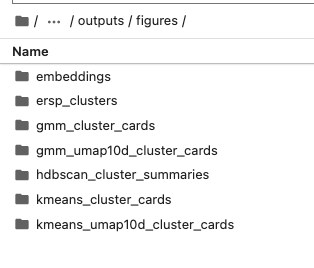


In [7]:
# Load data:
# 0. Config & imports
from pathlib import Path
import datetime
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier

from functions.lf_clustering import (
    load_ersp_all,
    run_umap_and_plot,
    select_best_k_by_silhouette,
)
from functions.lf_blob_metrics import (
    high_activity_screening,
    filter_high_activity,
    build_umap_features_from_shapes,
    init_blob_metric,
    ersp_blob_metric,
)
SCRIPT_NAME = "210_clustering.ipynb"
ALGO_TAG = "clustering_UMAPblobs"
RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

ANALYSIS_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora")
INPUT_DIR = ANALYSIS_ROOT / r"01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY"
FIGURES_EMBEDDINGS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/embeddings"

# 1. Load

df_meta,  ersp_list= load_ersp_all(
    INPUT_DIR,
    task="LM",
    n_freq=129,
    n_time=300,
    allowed_conditions=("audio", "picture", "reading"),
)

import pickle
from pathlib import Path

ANALYSIS_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora")
FEATURES_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

BLOB_PICKLE_PATH = FEATURES_DIR / "X_4blobs_7features.pkl"
META_PICKLE_PATH = FEATURES_DIR / "df_meta_blob4.pkl"

print("Saving X_blob_full to:", BLOB_PICKLE_PATH)
with open(BLOB_PICKLE_PATH, "wb") as f:
    pickle.dump(X_blob_full, f)

print("Saving df_meta (filtered) to:", META_PICKLE_PATH)
df_meta.to_pickle(META_PICKLE_PATH)

print("Done. Shapes:")
print("  X_blob_full:", X_blob_full.shape)
print("  df_meta    :", df_meta.shape)


Detected patient folders:
  - EL030
  - EL035
  - EL036
  - EL037
  - EL038
  - EL040
  - EL042
  - PAT_2868
  - PAT_3066
  - PAT_3301
  - PAT_3390
  - PAT_3415
  - PAT_3455
  - PAT_3780
  - PAT_3965
  - PAT_3975

Total patients detected: 16

Patient EL030 — conditions found: ['audio', 'picture', 'reading']
  Loading 89 files from condition 'audio'
  Loading 89 files from condition 'picture'
  Loading 89 files from condition 'reading'

Patient EL035 — conditions found: ['audio', 'picture', 'reading']
  Loading 118 files from condition 'audio'
  Loading 118 files from condition 'picture'
  Loading 118 files from condition 'reading'

Patient EL036 — conditions found: ['audio', 'picture', 'reading']
  Loading 63 files from condition 'audio'
  Loading 63 files from condition 'picture'
  Loading 63 files from condition 'reading'

Patient EL037 — conditions found: ['audio', 'picture', 'reading']
  Loading 118 files from condition 'audio'
  Loading 118 files from condition 'picture'
  Loading

In [1]:
import pickle
from pathlib import Path

ANALYSIS_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora")
FEATURES_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

BLOB_PICKLE_PATH = FEATURES_DIR / "X_4blobs_7features.pkl"
META_PICKLE_PATH = FEATURES_DIR / "df_meta_blob4.pkl"

print("Saving X_blob_full to:", BLOB_PICKLE_PATH)
with open(BLOB_PICKLE_PATH, "wb") as f:
    pickle.dump(X_blob_full, f)

print("Saving df_meta (filtered) to:", META_PICKLE_PATH)
df_meta.to_pickle(META_PICKLE_PATH)

print("Done. Shapes:")
print("  X_blob_full:", X_blob_full.shape)
print("  df_meta    :", df_meta.shape)


Saving X_blob_full to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\features\X_4blobs_7features.pkl


NameError: name 'X_blob_full' is not defined

In [ ]:
# ============================================================
# DRIVER: from precomputed blob features -> UMAP -> KMeans
#         + cluster cards + feature importance
#         (no ersp_list; df_meta + X_blob_full loaded from disk)
# ============================================================

from pathlib import Path
import datetime
import pickle
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier

from functions.lf_clustering import (
    run_umap_and_plot,
    select_best_k_by_silhouette,
    save_cluster_cards_with_blob_features,
    save_cluster_members_npy,
)
from functions.lf_blob_metrics import (
    init_blob_metric,
    ersp_blob_metric,
)

# ---------------------------------------------------------------------
# 0) Paths & config
# ---------------------------------------------------------------------
SCRIPT_NAME = "210_clustering_fromBlobs.ipynb"
ALGO_TAG    = "clustering_blob4"
RUN_ID      = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

ANALYSIS_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora")
FEATURES_DIR  = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/features"
FIGURES_EMBEDDINGS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/embeddings4blobs"
FIGURES_KMEANS_CLUSTER_CARDS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/kmeans_blob4_cluster_cards"
BEST_KMEANS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/kmeans_blob4_bestK"

for d in [FIGURES_EMBEDDINGS_DIR, FIGURES_KMEANS_CLUSTER_CARDS_DIR, BEST_KMEANS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BLOB_PICKLE_PATH = FEATURES_DIR / "X_4blobs_7features.pkl"
META_PICKLE_PATH = FEATURES_DIR / "df_meta_blob4.pkl"

RANDOM_STATE     = 42
MAX_BLOBS_FULL   = 4
FEATURES_PER_FULL = 7   # [t_start, f_peak, t_peak, sf, st, cov, mean_signed]

# ---------------------------------------------------------------------
# 1) Load df_meta + X_blob_full from disk
# ---------------------------------------------------------------------
df_meta = pd.read_pickle(META_PICKLE_PATH)
print("Loaded df_meta from:", META_PICKLE_PATH)
print("df_meta shape:", df_meta.shape)

with open(BLOB_PICKLE_PATH, "rb") as f:
    X_blob_full = pickle.load(f)
print("Loaded X_blob_full from:", BLOB_PICKLE_PATH)
print("X_blob_full shape:", X_blob_full.shape)

assert X_blob_full.shape[0] == len(df_meta), "Row mismatch between df_meta and X_blob_full!"

# ---------------------------------------------------------------------
# 2) Drop mean_signed from features for clustering
# ---------------------------------------------------------------------
# X_blob_full has 7 features per blob:
#   [t_start, f_peak, t_peak, sf, st, cov, mean_signed]
# For clustering we keep only the first 6 per blob.

FEATURES_PER_CLUST = 6
keep_cols = []
for b in range(MAX_BLOBS_FULL):
    base = b * FEATURES_PER_FULL
    keep_cols.extend([base + 0, base + 1, base + 2, base + 3, base + 4, base + 5])

X_blob_clust = X_blob_full[:, keep_cols].astype(np.float32)
print("X_blob_clust shape:", X_blob_clust.shape, "(mean_signed removed)")

MAX_BLOBS_CLUST = MAX_BLOBS_FULL
FEATURES_PER    = FEATURES_PER_CLUST  # 6

# ---------------------------------------------------------------------
# 3) Configure blob metric (no mean_signed) + UMAP visualization
# ---------------------------------------------------------------------
print("\n=== UMAP visualization of weighted blob-feature space (no mean_signed) ===")

init_blob_metric(
    max_blobs=MAX_BLOBS_CLUST,
    features_per_blob=FEATURES_PER,   # 6 features per blob now
    feature_type_weights={
        "t_start": 1.5,
        "f_peak":  1.5,
        "t_peak":  1.5,
        "sf":      1.2,
        "st":      1.2,
        "cov":     1.0,
        # mean_signed is not present in X_blob_clust at all
    },
)

umap_png = FIGURES_EMBEDDINGS_DIR / f"umap_blob_{ALGO_TAG}_{RUN_ID}.png"

embedding_blob, umap_model_blob = run_umap_and_plot(
    X_blob_clust,
    df_meta,
    n_neighbors=5,
    min_dist=0.05,
    metric=ersp_blob_metric,
    title_prefix="UMAP – weighted multi-blob features (no mean_signed)",
    ersp_list=None,   # no ERSP list in this driver
    n_step=None,      # no thumbnails
    thumb_zoom=0.12,
    save_path=umap_png,
)

# ---------------------------------------------------------------------
# 4) KMeans sweep on blob features (without mean_signed)
# ---------------------------------------------------------------------
print("\n=== KMeans sweep on blob features ===")

X_for_clustering = X_blob_clust
KMEANS_K_RANGE   = list(range(6, 37))  # 6–36 inclusive

kmeans_results    = []
kmeans_label_dict = {}
PLOT_KMEANS_CLUSTER_CARDS = True

for K in KMEANS_K_RANGE:
    print(f"\n--- KMeans (blob features) with K={K} ---")
    kmeans = KMeans(
        n_clusters=K,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    kmeans.fit(X_for_clustering)
    labels = kmeans.labels_

    inertia = float(kmeans.inertia_)
    unique_labels, counts = np.unique(labels, return_counts=True)

    if len(unique_labels) > 1:
        sil = float(silhouette_score(X_for_clustering, labels))
    else:
        sil = np.nan

    print("Inertia        :", inertia)
    print("Cluster counts :", dict(zip(unique_labels, counts)))
    print("Silhouette     :", sil)

    kmeans_results.append(
        {
            "algo": "kmeans_blob",
            "K": K,
            "inertia": inertia,
            "silhouette": sil,
            "n_clusters_found": int(len(unique_labels)),
        }
    )
    kmeans_label_dict[K] = labels.copy()

    if PLOT_KMEANS_CLUSTER_CARDS:
        param_tag = f"K{K}"
        save_cluster_cards_with_blob_features(
            df_meta=df_meta,
            labels=labels,
            ersp_list=None,           # let the function reload ERSPs from file_path
            X_blob=X_blob_full,
            algo_tag="kmeans_blob",
            param_tag=param_tag,
            out_dir=FIGURES_KMEANS_CLUSTER_CARDS_DIR,
            max_blobs=MAX_BLOBS_FULL,
            features_per_blob=FEATURES_PER_FULL,  # 7 for overlay (includes sign)
        )

        stem = f"kmeans_blob_{param_tag}_cluster_cards"
        npy_path = FIGURES_KMEANS_CLUSTER_CARDS_DIR / f"{stem}.npy"
        save_cluster_members_npy(df_meta, labels, npy_path)

print("\nKMeans sweep on blob features finished.")

# ---------------------------------------------------------------------
# 5) Best K by silhouette + save outputs
# ---------------------------------------------------------------------
print("\n=== Selecting best K by silhouette for KMeans on blob features (9 ≤ K ≤ 19) ===")
best_K_kmeans, best_sil_kmeans = select_best_k_by_silhouette(
    kmeans_results,
    k_key="K",
    sil_key="silhouette",
    k_min=9,
    k_max=19,
)

if best_K_kmeans is not None:
    print(f"[KMeans blob] Best K in (9,19): K={best_K_kmeans} (sil={best_sil_kmeans:.4f})")
    best_kmeans_labels = kmeans_label_dict[best_K_kmeans]

    df_meta["cluster_kmeans_blob_bestK"] = best_kmeans_labels

    best_labels_path = BEST_KMEANS_DIR / f"kmeans_blob_bestK_labels_K{best_K_kmeans}.npy"
    np.save(best_labels_path, best_kmeans_labels)
    print("[KMeans blob] Saved best-K labels to:", best_labels_path)

    out_tsv = (
        ANALYSIS_ROOT
        / r"02_FBM_Clustering/outputs/clustering/df_meta_with_kmeans_blob_bestK.tsv"
    )
    df_meta.to_csv(out_tsv, sep="\t", index=False)
    print("Saved df_meta with KMeans-blob best-K cluster column to:", out_tsv)
else:
    print("[KMeans blob] No valid K in (9,19) with non-NaN silhouette.")

# ---------------------------------------------------------------------
# 6) Feature importance – which blob features drive cluster assignment?
# ---------------------------------------------------------------------
if best_K_kmeans is not None:
    print("\n=== Feature-importance: which blob features drive clusters? ===")

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_for_clustering, best_kmeans_labels)

    importances = rf.feature_importances_
    assert importances.shape[0] == MAX_BLOBS_CLUST * FEATURES_PER

    feature_names = ["t_start", "f_peak", "t_peak", "sf", "st", "cov"]

    records = []
    for b in range(MAX_BLOBS_CLUST):
        for j, name in enumerate(feature_names):
            idx = b * FEATURES_PER + j
            records.append(
                {
                    "blob_idx": b,
                    "feature": name,
                    "global_index": idx,
                    "importance": importances[idx],
                }
            )
    imp_df = pd.DataFrame.from_records(records)

    total_imp = imp_df["importance"].sum()
    if total_imp > 0:
        imp_df["importance_norm"] = imp_df["importance"] / total_imp
    else:
        imp_df["importance_norm"] = 0.0

    print("\nTop 20 individual blob-features by importance:")
    display(
        imp_df.sort_values("importance_norm", ascending=False)
              .head(20)
              .reset_index(drop=True)
    )

    print("\nImportance aggregated by feature type (across blobs):")
    agg_kind = (
        imp_df.groupby("feature")["importance_norm"]
              .sum()
              .sort_values(ascending=False)
              .reset_index()
    )
    display(agg_kind)

    print("\nImportance aggregated by blob index (summing all 6 features):")
    agg_blob = (
        imp_df.groupby("blob_idx")["importance_norm"]
              .sum()
              .sort_values(ascending=False)
              .reset_index()
    )
    display(agg_blob)


ERSP shape: 129 freq × 300 time; samples=1549


====== High-Activity Electrode Filtering ======

Total electrodes before filtering: 1549

High-activity electrodes kept:    1549

Low-activity electrodes removed:  0

===============================================

After filtering:
  df_meta rows: 1549
  ersp_list len: 1549
  shape_list len: 1549
After filtering: 1549 high-activity ERSPs.

=== Building blob features (X_blob_full) ===

X_umap shape for UMAP (up to 4 blobs × 7 features): (1549, 28)

Saved X_blob_full to: 

\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\X_4blobs_7features.pkl

Reloaded X_blob_full from: 

\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\X_4blobs_7features.pkl
X_blob_full shape after reload: (1549, 28)

In [3]:
# # ============================================================
# # DRIVER: from ERSPs -> blob features -> KMeans on features
# #         + UMAP viz + cluster cards with blob overlays
# #         + .npy membership + feature-importance summary
# # ============================================================

# from pathlib import Path
# import datetime
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from IPython.display import display

# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score
# from sklearn.ensemble import RandomForestClassifier

# from functions.lf_clustering import (
#     run_umap_and_plot,
#     select_best_k_by_silhouette,
#     save_cluster_cards_with_blob_features,
#     save_cluster_members_npy,
# )
# from functions.lf_blob_metrics import (
#     high_activity_screening,
#     filter_high_activity,
#     build_umap_features_from_shapes,
#     init_blob_metric,
#     ersp_blob_metric,
# )

# # ---------------------------------------------------------------------
# # 0) Config (matches your notebook)
# # ---------------------------------------------------------------------
# SCRIPT_NAME = "210_clustering_UMAP20.ipynb"
# ALGO_TAG    = "clustering_blob4"
# RUN_ID      = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# ANALYSIS_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora")
# FIGURES_EMBEDDINGS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/embeddings4blobs"
# FIGURES_KMEANS_CLUSTER_CARDS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/kmeans_blob4_cluster_cards"
# BEST_KMEANS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/kmeans_blob4_bestK"

# for d in [FIGURES_EMBEDDINGS_DIR, FIGURES_KMEANS_CLUSTER_CARDS_DIR, BEST_KMEANS_DIR]:
#     d.mkdir(parents=True, exist_ok=True)

# RANDOM_STATE = 42
# MAX_BLOBS_FULL    = 4
# FEATURES_PER = 7  # [t_start, f_peak, t_peak, sf, st, cov, mean_signed]

# # ---------------------------------------------------------------------
# # 1) Data already loaded in previous cell:
# #     df_meta, ersp_list = load_ersp_all(...)
# # ---------------------------------------------------------------------
# N_FREQ, N_TIME = ersp_list[0].shape
# print(f"ERSP shape: {N_FREQ} freq × {N_TIME} time; samples={len(ersp_list)}")


# # ---------------------------------------------------------------------
# # 2) High-activity screening + filtering
# # ---------------------------------------------------------------------
# thr_pos       = 2.0
# thr_neg       = -3.0
# min_prop_pos  = 0.02
# min_prop_neg  = 0.08

# print("\n=== High-activity screening ===")
# prop_pos, prop_neg, high_flags, shape_list = high_activity_screening(
#     ersp_list,
#     thr_pos=thr_pos,
#     min_prop_pos=min_prop_pos,
#     thr_neg=thr_neg,
#     min_prop_neg=min_prop_neg,
#     round_decimals=1,
# )

# df_meta["prop_above_pos"] = prop_pos
# df_meta["prop_below_neg"] = prop_neg
# df_meta["high_activity"]  = high_flags

# df_meta, ersp_list, shape_list = filter_high_activity(
#     df_meta, ersp_list, shape_list, high_flags
# )

# N_FREQ, N_TIME = ersp_list[0].shape
# print(f"After filtering: {len(ersp_list)} high-activity ERSPs.")


# # ---------------------------------------------------------------------
# # 3) Build blob features (X_blob)
# # ---------------------------------------------------------------------
# MAX_BLOBS_FULL    = 4
# FEATURES_PER = 7  # [t_start, f_peak, t_peak, sf, st, cov, mean_signed]


# print("\n=== Building blob features (X_blob_full) ===")
# X_blob_full = build_umap_features_from_shapes(
#     shape_list=shape_list,
#     ersp_list=ersp_list,
#     max_blobs=MAX_BLOBS_FULL,
# )


# # -------------------------------------------------
# # Save X_blob_full once as a pickle (run once)
# # -------------------------------------------------
# XDATA_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs"
# XDATA_DIR.mkdir(parents=True, exist_ok=True)

# blob_pickle_path = XDATA_DIR / "X_4blobs_7features.pkl"

# with open(blob_pickle_path, "wb") as f:
#     pickle.dump(X_blob_full, f, protocol=pickle.HIGHEST_PROTOCOL)

# print("Saved X_blob_full to:", blob_pickle_path)

# # -------------------------------------------------
# # Immediately reload (for testing / later reuse)
# # -------------------------------------------------
# with open(blob_pickle_path, "rb") as f:
#     X_blob_full = pickle.load(f)

# print("Reloaded X_blob_full from:", blob_pickle_path)
# print("X_blob_full shape after reload:", X_blob_full.shape)


ERSP shape: 129 freq × 300 time; samples=1549

=== High-activity screening ===
====== High-Activity Electrode Filtering ======
Total electrodes before filtering: 1549
High-activity electrodes kept:    1549
Low-activity electrodes removed:  0

After filtering:
  df_meta rows: 1549
  ersp_list len: 1549
  shape_list len: 1549
After filtering: 1549 high-activity ERSPs.

=== Building blob features (X_blob_full) ===
X_umap shape for UMAP (up to 4 blobs × 7 features): (1549, 28)
Saved X_blob_full to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\X_4blobs_7features.pkl
Reloaded X_blob_full from: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\X_4blobs_7features.pkl
X_blob_full shape after reload: (1549, 28)


In [5]:


# ---- IMMEDIATELY RELOAD FROM PICKLE ----
with open(BLOB_PICKLE_PATH, "rb") as f:
    X_blob_full = pickle.load(f)
print("Reloaded X_blob_full from:", BLOB_PICKLE_PATH)
print("X_blob_full shape after reload:", X_blob_full.shape)

# X_blob_full has 7 features per blob:
# [t_start, f_peak, t_peak, sf, st, cov, mean_signed]
# We want to REMOVE mean_signed (last feature of each blob) for clustering.

FEATURES_PER_CLUST = 6  # we will keep only first 6 features per blob
keep_cols = []
for b in range(MAX_BLOBS_FULL):
    base = b * FEATURES_PER_FULL
    # keep: t_start, f_peak, t_peak, sf, st, cov
    keep_cols.extend([base + 0, base + 1, base + 2, base + 3, base + 4, base + 5])

X_blob_clust = X_blob_full[:, keep_cols].astype(np.float32)
print("X_blob_clust shape:", X_blob_clust.shape, "(mean_signed removed)")

# For clustering / UMAP, we now treat:
MAX_BLOBS_CLUST = MAX_BLOBS_FULL
FEATURES_PER    = FEATURES_PER_CLUST   # 6


# ---------------------------------------------------------------------
# 4) Configure blob metric (no mean_signed) + UMAP visualization
# ---------------------------------------------------------------------
print("\n=== UMAP visualization of weighted blob-feature space (no mean_signed) ===")

init_blob_metric(
    max_blobs=MAX_BLOBS_CLUST,
    features_per_blob=FEATURES_PER,   # 6 features per blob now
    feature_type_weights={
        "t_start": 1.5,
        "f_peak":  1.5,
        "t_peak":  1.5,
        "sf":      1.2,
        "st":      1.2,
        "cov":     1.0,
        # mean_signed is not present in X_blob_clust at all
    },
)

umap_png = FIGURES_EMBEDDINGS_DIR / f"umap_blob_{ALGO_TAG}_{RUN_ID}.png"

embedding_blob, umap_model_blob = run_umap_and_plot(
    X_blob_clust,          # <-- clustering feature space without mean_signed
    df_meta,
    n_neighbors=5,
    min_dist=0.05,
    metric=ersp_blob_metric,
    title_prefix="UMAP – weighted multi-blob features (no mean_signed)",
    ersp_list=ersp_list,
    n_step=20,
    thumb_zoom=0.12,
    save_path=umap_png,
)


# ---------------------------------------------------------------------
# 5) KMeans sweep on blob features (without mean_signed)
# ---------------------------------------------------------------------
print("\n=== KMeans sweep on blob features ===")

X_for_clustering = X_blob_clust  # (N_samples, 4 * 6)

KMEANS_K_RANGE   = list(range(6, 37))  # 6–36 inclusive

kmeans_results    = []
kmeans_label_dict = {}
PLOT_KMEANS_CLUSTER_CARDS = True

for K in KMEANS_K_RANGE:
    print(f"\n--- KMeans (blob features) with K={K} ---")
    kmeans = KMeans(
        n_clusters=K,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    kmeans.fit(X_for_clustering)
    labels = kmeans.labels_

    inertia = float(kmeans.inertia_)
    unique_labels, counts = np.unique(labels, return_counts=True)

    if len(unique_labels) > 1:
        sil = float(silhouette_score(X_for_clustering, labels))
    else:
        sil = np.nan

    print("Inertia        :", inertia)
    print("Cluster counts :", dict(zip(unique_labels, counts)))
    print("Silhouette     :", sil)

    kmeans_results.append(
        {
            "algo": "kmeans_blob",
            "K": K,
            "inertia": inertia,
            "silhouette": sil,
            "n_clusters_found": int(len(unique_labels)),
        }
    )
    kmeans_label_dict[K] = labels.copy()

    if PLOT_KMEANS_CLUSTER_CARDS:
        param_tag = f"K{K}"
        # cluster cards with blob overlays:
        #   - use X_blob_full (has mean_signed if overlay wants it)
        #   - tell it features_per_blob=7 for the overlay parsing
        save_cluster_cards_with_blob_features(
            df_meta=df_meta,
            labels=labels,
            ersp_list=ersp_list,
            X_blob=X_blob_full,
            algo_tag="kmeans_blob",
            param_tag=param_tag,
            out_dir=FIGURES_KMEANS_CLUSTER_CARDS_DIR,
            n_freq=N_FREQ,
            n_time=N_TIME,
            max_blobs=MAX_BLOBS_FULL,
            features_per_blob=FEATURES_PER_FULL,  # 7 in the overlay
        )

        # membership .npy for later reconstructions
        stem = f"kmeans_blob_{param_tag}_cluster_cards"
        npy_path = FIGURES_KMEANS_CLUSTER_CARDS_DIR / f"{stem}.npy"
        save_cluster_members_npy(df_meta, labels, npy_path)

print("\nKMeans sweep on blob features finished.")


# ---------------------------------------------------------------------
# 6) Best K by silhouette + save outputs
# ---------------------------------------------------------------------
print("\n=== Selecting best K by silhouette for KMeans on blob features (9 ≤ K ≤ 19) ===")
best_K_kmeans, best_sil_kmeans = select_best_k_by_silhouette(
    kmeans_results,
    k_key="K",
    sil_key="silhouette",
    k_min=9,
    k_max=19,
)

if best_K_kmeans is not None:
    print(f"[KMeans blob] Best K in (9,19): K={best_K_kmeans} (sil={best_sil_kmeans:.4f})")
    best_kmeans_labels = kmeans_label_dict[best_K_kmeans]

    df_meta["cluster_kmeans_blob_bestK"] = best_kmeans_labels

    best_labels_path = BEST_KMEANS_DIR / f"kmeans_blob_bestK_labels_K{best_K_kmeans}.npy"
    np.save(best_labels_path, best_kmeans_labels)
    print("[KMeans blob] Saved best-K labels to:", best_labels_path)

    out_tsv = (
        ANALYSIS_ROOT
        / r"02_FBM_Clustering/outputs/clustering/df_meta_with_kmeans_blob_bestK.tsv"
    )
    df_meta.to_csv(out_tsv, sep="\t", index=False)
    print("Saved df_meta with KMeans-blob best-K cluster column to:", out_tsv)
else:
    print("[KMeans blob] No valid K in (9,19) with non-NaN silhouette.")


# ---------------------------------------------------------------------
# 7) Feature importance – which blob features drive cluster assignment?
# ---------------------------------------------------------------------
if best_K_kmeans is not None:
    print("\n=== Feature-importance: which blob features drive clusters? ===")

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_for_clustering, best_kmeans_labels)

    importances = rf.feature_importances_
    assert importances.shape[0] == MAX_BLOBS_CLUST * FEATURES_PER

    # Only 6 features now (no mean_signed):
    feature_names = ["t_start", "f_peak", "t_peak", "sf", "st", "cov"]

    records = []
    for b in range(MAX_BLOBS_CLUST):
        for j, name in enumerate(feature_names):
            idx = b * FEATURES_PER + j
            records.append(
                {
                    "blob_idx": b,
                    "feature": name,
                    "global_index": idx,
                    "importance": importances[idx],
                }
            )
    imp_df = pd.DataFrame.from_records(records)

    total_imp = imp_df["importance"].sum()
    if total_imp > 0:
        imp_df["importance_norm"] = imp_df["importance"] / total_imp
    else:
        imp_df["importance_norm"] = 0.0

    print("\nTop 20 individual blob-features by importance:")
    display(
        imp_df.sort_values("importance_norm", ascending=False)
              .head(20)
              .reset_index(drop=True)
    )

    print("\nImportance aggregated by feature type (across blobs):")
    agg_kind = (
        imp_df.groupby("feature")["importance_norm"]
              .sum()
              .sort_values(ascending=False)
              .reset_index()
    )
    display(agg_kind)

    print("\nImportance aggregated by blob index (summing all 6 features):")
    agg_blob = (
        imp_df.groupby("blob_idx")["importance_norm"]
              .sum()
              .sort_values(ascending=False)
              .reset_index()
    )
    display(agg_blob)


NameError: name 'BLOB_PICKLE_PATH' is not defined

ERSP shape: 129 freq × 300 time; samples=1549

=== High-activity screening ===
====== High-Activity Electrode Filtering ======
Total electrodes before filtering: 1549
High-activity electrodes kept:    1549
Low-activity electrodes removed:  0

After filtering:
  df_meta rows: 1549
  ersp_list len: 1549
  shape_list len: 1549
After filtering: 1549 high-activity ERSPs.

=== Building blob features (X_blob) ===
X_umap shape for UMAP (up to 4 blobs × 7 features): (1549, 28)

=== UMAP visualization of weighted blob-feature space ===
[init_blob_metric] Configured 4 blobs × 7 features = 28D feature space.
[init_blob_metric] Base feature-type weights per blob: [1.5 1.5 1.5 1.2 1.2 1.  0. ]
[init_blob_metric] Example of first 7 weights in full vector: [1.5 1.5 1.5 1.2 1.2 1.  0. ]


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding done: shape=(1549, 2), n_neighbors=5, min_dist=0.05, metric=<function ersp_blob_metric at 0x000001C57EA13910>
Saved UMAP figure to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\embeddings4blobs\umap_blob_clustering_blob4_20251210_180628.png


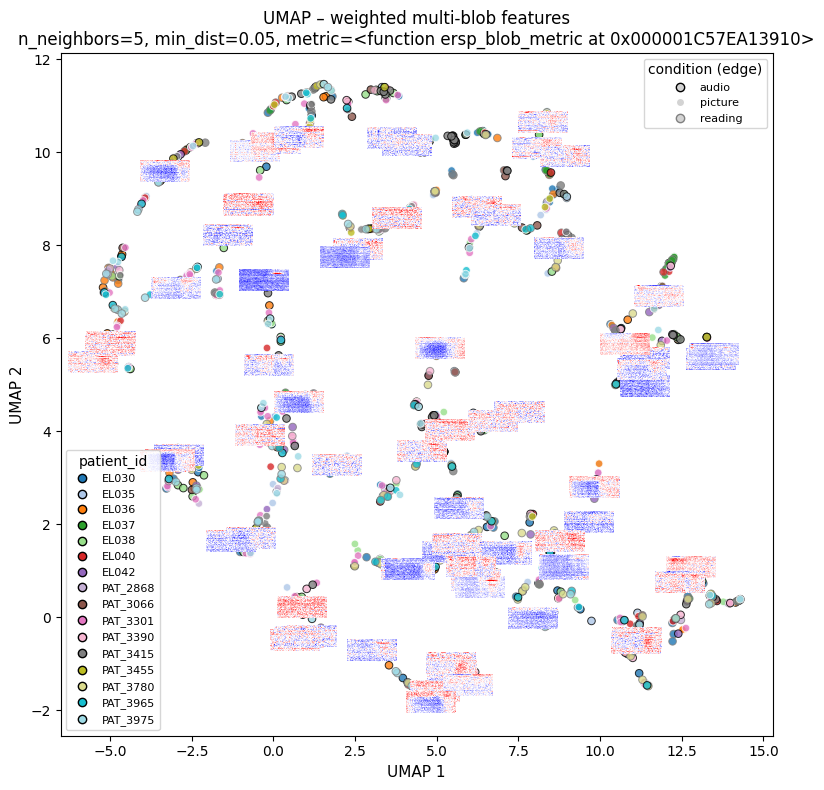


=== KMeans sweep on blob features ===

--- KMeans (blob features) with K=6 ---
Inertia        : 7720.78369140625
Cluster counts : {0: 819, 1: 153, 2: 80, 3: 173, 4: 171, 5: 153}
Silhouette     : 0.6410631537437439
[kmeans_blob K6] Saved cluster cards to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\kmeans_blob4_cluster_cards\kmeans_blob_K6_cluster_cards.png
[cluster_members] Saved membership .npy to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\kmeans_blob4_cluster_cards\kmeans_blob_K6_cluster_cards.npy

--- KMeans (blob features) with K=7 ---
Inertia        : 6495.35595703125
Cluster counts : {0: 819, 1: 126, 2: 149, 3: 169, 4: 144, 5: 85, 6: 57}
Silhouette     : 0.6607761979103088
[kmeans_blob K7] Saved cluster cards to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\kmeans_blob4_cluster_cards\kmeans_blob_K7_cluster_cards.png
[c

,blob_idx,feature,global_index,importance,importance_norm
0,1,mean_signed,13,0.195187,0.195187
1,2,mean_signed,20,0.188936,0.188936
2,3,mean_signed,27,0.181000,0.181000
3,0,mean_signed,6,0.166012,0.166012
4,2,f_peak,15,0.022368,0.022368
5,1,f_peak,8,0.018797,0.018797
6,3,f_peak,22,0.016993,0.016993
7,0,f_peak,1,0.016060,0.016060
8,3,st,25,0.013993,0.013993
9,3,t_start,21,0.013111,0.013111



Importance aggregated by feature type (across blobs):


,feature,importance_norm
0,mean_signed,0.731136
1,f_peak,0.074217
2,st,0.046996
3,sf,0.041556
4,t_start,0.036851
5,t_peak,0.036036
6,cov,0.033208



Importance aggregated by blob index (summing all 7 features):


,blob_idx,importance_norm
0,2,0.265626
1,3,0.258161
2,1,0.256606
3,0,0.219608


In [5]:

# ---------------------------------------------------------------------
# 4) Configure blob metric + UMAP visualization
# ---------------------------------------------------------------------
print("\n=== UMAP visualization of weighted blob-feature space ===")

# Configure metric + per-feature-type weights
init_blob_metric(
    max_blobs=MAX_BLOBS,
    features_per_blob=FEATURES_PER,
    feature_type_weights={
        "t_start": 1.5,
        "f_peak":  1.5,
        "t_peak":  1.5,
        "sf":      1.2,
        "st":      1.2,
        "cov":     1.0,
        "mean_signed": 0.0,  # downweight sign so geometry matters more
    },
)

umap_png = FIGURES_EMBEDDINGS_DIR / f"umap_blob_{ALGO_TAG}_{RUN_ID}.png"

embedding_blob, umap_model_blob = run_umap_and_plot(
    X_blob,
    df_meta,
    n_neighbors=5,
    min_dist=0.05,
    metric=ersp_blob_metric,             # weighted Euclidean in blob space
    title_prefix="UMAP – weighted multi-blob features",
    ersp_list=ersp_list,
    n_step=20,
    thumb_zoom=0.12,
    save_path=umap_png,
)


# ---------------------------------------------------------------------
# 5) KMeans sweep on blob features
# ---------------------------------------------------------------------
print("\n=== KMeans sweep on blob features ===")

X_for_clustering = X_blob.astype(np.float32)
KMEANS_K_RANGE   = list(range(6, 37))  # 6–36 inclusive

kmeans_results    = []
kmeans_label_dict = {}
PLOT_KMEANS_CLUSTER_CARDS = True

for K in KMEANS_K_RANGE:
    print(f"\n--- KMeans (blob features) with K={K} ---")
    kmeans = KMeans(
        n_clusters=K,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    kmeans.fit(X_for_clustering)
    labels = kmeans.labels_

    inertia = float(kmeans.inertia_)
    unique_labels, counts = np.unique(labels, return_counts=True)

    if len(unique_labels) > 1:
        sil = float(silhouette_score(X_for_clustering, labels))
    else:
        sil = np.nan

    print("Inertia        :", inertia)
    print("Cluster counts :", dict(zip(unique_labels, counts)))
    print("Silhouette     :", sil)

    kmeans_results.append(
        {
            "algo": "kmeans_blob",
            "K": K,
            "inertia": inertia,
            "silhouette": sil,
            "n_clusters_found": int(len(unique_labels)),
        }
    )
    kmeans_label_dict[K] = labels.copy()

    if PLOT_KMEANS_CLUSTER_CARDS:
        param_tag = f"K{K}"
        # cluster cards with blob overlays + feature markers
        save_cluster_cards_with_blob_features(
            df_meta=df_meta,
            labels=labels,
            ersp_list=ersp_list,
            X_blob=X_blob,
            algo_tag="kmeans_blob",
            param_tag=param_tag,
            out_dir=FIGURES_KMEANS_CLUSTER_CARDS_DIR,
            n_freq=N_FREQ,
            n_time=N_TIME,
            max_blobs=MAX_BLOBS,
            features_per_blob=FEATURES_PER,
        )

        # membership .npy for later anatomy-based reconstructions
        stem = f"kmeans_blob_{param_tag}_cluster_cards"
        npy_path = FIGURES_KMEANS_CLUSTER_CARDS_DIR / f"{stem}.npy"
        save_cluster_members_npy(df_meta, labels, npy_path)

print("\nKMeans sweep on blob features finished.")


# ---------------------------------------------------------------------
# 6) Best K by silhouette + save outputs
# ---------------------------------------------------------------------
print("\n=== Selecting best K by silhouette for KMeans on blob features (9 ≤ K ≤ 19) ===")
best_K_kmeans, best_sil_kmeans = select_best_k_by_silhouette(
    kmeans_results,
    k_key="K",
    sil_key="silhouette",
    k_min=9,
    k_max=19,
)

if best_K_kmeans is not None:
    print(f"[KMeans blob] Best K in (9,19): K={best_K_kmeans} (sil={best_sil_kmeans:.4f})")
    best_kmeans_labels = kmeans_label_dict[best_K_kmeans]

    df_meta["cluster_kmeans_blob_bestK"] = best_kmeans_labels

    best_labels_path = BEST_KMEANS_DIR / f"kmeans_blob_bestK_labels_K{best_K_kmeans}.npy"
    np.save(best_labels_path, best_kmeans_labels)
    print("[KMeans blob] Saved best-K labels to:", best_labels_path)

    out_tsv = (
        ANALYSIS_ROOT
        / r"02_FBM_Clustering/outputs/clustering/df_meta_with_kmeans_blob_bestK.tsv"
    )
    df_meta.to_csv(out_tsv, sep="\t", index=False)
    print("Saved df_meta with KMeans-blob best-K cluster column to:", out_tsv)
else:
    print("[KMeans blob] No valid K in (9,19) with non-NaN silhouette.")


# ---------------------------------------------------------------------
# 7) Feature importance – which blob features drive cluster assignment?
# ---------------------------------------------------------------------
if best_K_kmeans is not None:
    print("\n=== Feature-importance: which blob features drive clusters? ===")

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_for_clustering, best_kmeans_labels)

    importances = rf.feature_importances_
    assert importances.shape[0] == MAX_BLOBS * FEATURES_PER

    feature_names = ["t_start", "f_peak", "t_peak", "sf", "st", "cov", "mean_signed"]

    records = []
    for b in range(MAX_BLOBS):
        for j, name in enumerate(feature_names):
            idx = b * FEATURES_PER + j
            records.append(
                {
                    "blob_idx": b,
                    "feature": name,
                    "global_index": idx,
                    "importance": importances[idx],
                }
            )
    imp_df = pd.DataFrame.from_records(records)

    total_imp = imp_df["importance"].sum()
    if total_imp > 0:
        imp_df["importance_norm"] = imp_df["importance"] / total_imp
    else:
        imp_df["importance_norm"] = 0.0

    print("\nTop 20 individual blob-features by importance:")
    display(
        imp_df.sort_values("importance_norm", ascending=False)
              .head(20)
              .reset_index(drop=True)
    )

    print("\nImportance aggregated by feature type (across blobs):")
    agg_kind = (
        imp_df.groupby("feature")["importance_norm"]
              .sum()
              .sort_values(ascending=False)
              .reset_index()
    )
    display(agg_kind)

    print("\nImportance aggregated by blob index (summing all 7 features):")
    agg_blob = (
        imp_df.groupby("blob_idx")["importance_norm"]
              .sum()
              .sort_values(ascending=False)
              .reset_index()
    )
    display(agg_blob)


In [3]:
# from functions.lf_blob_metrics import (
#     init_blob_metric,
#     ersp_blob_metric,
#     high_activity_screening,
#     filter_high_activity,
#     build_umap_features_from_shapes,
# )

# # ============================================
# # High-activity → blob features → UMAP(2D) → KMeans on blob features
# # ============================================

# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

# RANDOM_STATE = 42

# # Infer data shape from loaded ERSPs
# N_FREQ, N_TIME = ersp_list[0].shape

# # ---------------------------------------------------------------------
# # 1) High-activity screening → shape_list
# # ---------------------------------------------------------------------
# thr_pos, thr_neg = 2.5, -4.0
# min_prop_pos, min_prop_neg = 0.03, 0.08

# prop_pos, prop_neg, high_flags, shape_list = high_activity_screening(
#     ersp_list,
#     thr_pos=thr_pos,
#     min_prop_pos=min_prop_pos,
#     thr_neg=thr_neg,
#     min_prop_neg=min_prop_neg,
#     round_decimals=1,
# )

# df_meta["prop_above_pos"] = prop_pos
# df_meta["prop_below_neg"] = prop_neg
# df_meta["high_activity"] = high_flags

# # Keep only high-activity electrodes
# df_meta, ersp_list, shape_list = filter_high_activity(
#     df_meta, ersp_list, shape_list, high_flags
# )

# # Update shape constants after filtering (just in case)
# N_FREQ, N_TIME = ersp_list[0].shape

# # ---------------------------------------------------------------------
# # 2) Build blob-feature matrix X_blob from shape_list + ERSP
# #    (up to 4 blobs × 7 features each)
# # ---------------------------------------------------------------------
# MAX_BLOBS = 4

# X_blob = build_umap_features_from_shapes(
#     shape_list=shape_list,
#     ersp_list=ersp_list,
#     max_blobs=MAX_BLOBS,
# )

# print("X_blob feature matrix shape:", X_blob.shape)

# # Configure blob metric (for book-keeping; metric works in blob space)
# init_blob_metric(
#     n_freq=N_FREQ,
#     n_time=N_TIME,
#     max_blobs=MAX_BLOBS,
#     features_per_blob=7,  # [t_start, f_peak, t_peak, sf, st, cov, mean_signed]
# )

# # ---------------------------------------------------------------------
# # 3) 2D UMAP on blob features (for visualization only)
# # ---------------------------------------------------------------------
# umap_png = FIGURES_EMBEDDINGS_DIR / f"umap_blob_{ALGO_TAG}_{RUN_ID}.png"

# embedding_blob, umap_model_blob = run_umap_and_plot(
#     X_blob,
#     df_meta,
#     n_neighbors=5,
#     min_dist=0.05,
#     metric=ersp_blob_metric,  # distance in blob-feature space
#     title_prefix="UMAP – blob features (t_start, peaks, spreads, sign)",
#     ersp_list=ersp_list,
#     n_step=20,
#     thumb_zoom=0.12,
#     save_path=umap_png,       # if your run_umap_and_plot doesn't have this, remove this argument
# )

# # This is the space we will cluster on (NO UMAP-10D anymore)
# X_for_clustering = X_blob

# # ---------------------------------------------------------------------
# # 4) Helper: cluster cards (mean ERSP + condition stripe)
# # ---------------------------------------------------------------------
# def save_cluster_cards_generic(
#     df_meta,
#     labels,
#     ersp_list,
#     algo_tag: str,
#     param_tag: str,
#     out_dir: Path,
#     n_freq: int = N_FREQ,
#     n_time: int = N_TIME,
# ):
#     if len(df_meta) != len(labels):
#         raise ValueError(f"df_meta ({len(df_meta)}) != labels ({len(labels)})")
#     if len(ersp_list) != len(labels):
#         raise ValueError(f"ersp_list ({len(ersp_list)}) != labels ({len(labels)})")

#     df = df_meta.copy()
#     df["cluster_tmp"] = labels
#     cluster_ids = sorted(np.unique(labels))
#     if not cluster_ids:
#         print(f"[{algo_tag} {param_tag}] No clusters to summarize.")
#         return

#     # Conditions + colors
#     condition_order = sorted(df["condition"].unique())
#     default_colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"]
#     condition_colors = {
#         c: default_colors[i % len(default_colors)]
#         for i, c in enumerate(condition_order)
#     }

#     # Stats + condition counts + cluster-mean ERSPs
#     cluster_sizes, el_counts, pat_counts = [], [], []
#     cluster_cond_counts, cluster_means = {}, []

#     for c in cluster_ids:
#         df_c = df[df["cluster_tmp"] == c]
#         cluster_sizes.append(len(df_c))

#         patients = df_c["patient_id"].unique()
#         el_counts.append(sum(str(p).startswith("EL")  for p in patients))
#         pat_counts.append(sum(str(p).startswith("PAT") for p in patients))

#         cond_counts = (
#             df_c.groupby("condition")
#                .size()
#                .reindex(condition_order, fill_value=0)
#         )
#         cluster_cond_counts[c] = cond_counts

#         idx_c = np.where(labels == c)[0]
#         if len(idx_c) == 0:
#             cluster_means.append(None)
#         else:
#             arr_c = np.stack([ersp_list[i] for i in idx_c], axis=0)
#             cluster_means.append(arr_c.mean(axis=0))

#     max_cluster_size = max(cluster_sizes) if cluster_sizes else 0

#     # Color scale across all cluster means
#     vals = [mc.ravel() for mc in cluster_means if mc is not None]
#     if vals:
#         vals = np.concatenate(vals)
#         vmax = np.nanmax(np.abs(vals))
#         vmin = -vmax
#     else:
#         vmin = vmax = None

#     # Layout: squished vertically (stripe + ERSP)
#     n_clusters = len(cluster_ids)
#     n_cols = min(4, n_clusters)
#     n_card_rows = int(np.ceil(n_clusters / n_cols))
#     n_grid_rows = n_card_rows * 2

#     height_ratios = []
#     for _ in range(n_card_rows):
#         height_ratios.extend([0.25, 0.75])  # thin stripe, slightly taller ERSP

#     fig_width  = 1.4 * n_cols + 3.0
#     fig_height = 2.0 * n_card_rows + 1.5

#     fig = plt.figure(figsize=(fig_width, fig_height))
#     gs = GridSpec(
#         nrows=n_grid_rows,
#         ncols=n_cols,
#         height_ratios=height_ratios,
#         figure=fig,
#     )

#     legends_done = False

#     for idx, (c, mean_c, size_c, n_el, n_pat) in enumerate(
#         zip(cluster_ids, cluster_means, cluster_sizes, el_counts, pat_counts)
#     ):
#         card_row  = idx // n_cols
#         col       = idx % n_cols
#         stripe_row = 2 * card_row
#         ersp_row   = 2 * card_row + 1

#         ax_stripe = fig.add_subplot(gs[stripe_row, col])
#         ax_ersp   = fig.add_subplot(gs[ersp_row, col])

#         # --- condition stripe ---
#         cond_counts = cluster_cond_counts[c]
#         total_c = cond_counts.sum()
#         fractions = cond_counts / total_c if total_c > 0 else cond_counts * 0.0

#         left = 0.0
#         for cond in condition_order:
#             frac = fractions.loc[cond]
#             if frac <= 0:
#                 continue
#             ax_stripe.barh(
#                 0,
#                 frac,
#                 left=left,
#                 color=condition_colors.get(cond, "gray"),
#                 edgecolor="none",
#                 height=1.0,
#             )
#             left += frac

#         ax_stripe.set_xlim(0, 1)
#         ax_stripe.set_ylim(-0.6, 0.6)
#         ax_stripe.axis("off")

#         # --- mean ERSP heatmap ---
#         if mean_c is None:
#             ax_ersp.set_title(f"C{c} (empty)", fontsize=7)
#             ax_ersp.axis("off")
#         else:
#             ax_ersp.imshow(
#                 mean_c,
#                 aspect="auto",
#                 origin="lower",
#                 cmap="bwr",
#                 vmin=vmin,
#                 vmax=vmax,
#                 interpolation="nearest",
#             )
#             ax_ersp.set_title(
#                 f"C{c} (n={size_c}, max={max_cluster_size})\nEL:{n_el} | PAT:{n_pat}",
#                 fontsize=7,
#             )
#             ax_ersp.set_xlabel("Time", fontsize=6)
#             ax_ersp.set_ylabel("Freq", fontsize=6)
#             ax_ersp.tick_params(axis="both", labelsize=5)

#         # one legend for conditions
#         if not legends_done:
#             handles, labels_ = [], []
#             for cond in condition_order:
#                 handles.append(
#                     plt.Line2D(
#                         [0], [0],
#                         marker="s",
#                         linestyle="",
#                         markersize=5,
#                         color=condition_colors.get(cond, "gray"),
#                     )
#                 )
#                 labels_.append(cond)
#             ax_ersp.legend(
#                 handles, labels_,
#                 title="Condition",
#                 fontsize=5,
#                 loc="upper right",
#             )
#             legends_done = True

#     fig.suptitle(f"{algo_tag} cluster cards – {param_tag}", fontsize=10)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])

#     out_dir.mkdir(parents=True, exist_ok=True)
#     out_name = f"{algo_tag}_{param_tag}_cluster_cards.png"
#     out_path = out_dir / out_name
#     plt.savefig(out_path, dpi=150)
#     plt.close(fig)
#     print(f"[{algo_tag} {param_tag}] Saved cluster cards to:", out_path)


# # ---------------------------------------------------------------------
# # 5) KMeans sweep directly on blob features
# # ---------------------------------------------------------------------
# print("\n=== KMeans sweep on blob features (X_blob) ===")

# FIGURES_KMEANS_CLUSTER_CARDS_DIR = (
#     ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/kmeans_blob_cluster_cards"
# )
# FIGURES_KMEANS_CLUSTER_CARDS_DIR.mkdir(parents=True, exist_ok=True)

# BEST_KMEANS_DIR = (
#     ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/kmeans_blob_bestK"
# )
# BEST_KMEANS_DIR.mkdir(parents=True, exist_ok=True)

# KMEANS_K_RANGE = list(range(6, 37))  # 6–36 inclusive

# kmeans_results = []
# kmeans_label_dict = {}

# PLOT_KMEANS_CLUSTER_CARDS = True  # set False if you only want scores

# for K in KMEANS_K_RANGE:
#     print(f"\n--- KMeans on blob features with K={K} ---")
#     kmeans = KMeans(
#         n_clusters=K,
#         init="k-means++",
#         n_init=20,
#         max_iter=300,
#         random_state=RANDOM_STATE,
#         verbose=0,
#     )
#     kmeans.fit(X_for_clustering)
#     labels = kmeans.labels_

#     inertia = float(kmeans.inertia_)
#     unique_labels, counts = np.unique(labels, return_counts=True)

#     if len(unique_labels) > 1:
#         sil = float(silhouette_score(X_for_clustering, labels))
#     else:
#         sil = np.nan

#     print("Inertia        :", inertia)
#     print("Cluster counts :", dict(zip(unique_labels, counts)))
#     print("Silhouette     :", sil)

#     kmeans_results.append(
#         {
#             "algo": "kmeans_blob",
#             "K": K,
#             "inertia": inertia,
#             "silhouette": sil,
#             "n_clusters_found": int(len(unique_labels)),
#         }
#     )
#     kmeans_label_dict[K] = labels.copy()

#     if PLOT_KMEANS_CLUSTER_CARDS:
#         save_cluster_cards_generic(
#             df_meta=df_meta,
#             labels=labels,
#             ersp_list=ersp_list,
#             algo_tag="kmeans_blob",
#             param_tag=f"K{K}",
#             out_dir=FIGURES_KMEANS_CLUSTER_CARDS_DIR,
#             n_freq=N_FREQ,
#             n_time=N_TIME,
#         )

# print("\nKMeans sweep on blob features finished.")


# # ---------------------------------------------------------------------
# # 6) Pick best K (8 < K < 20) by silhouette + save outputs
# # ---------------------------------------------------------------------
# def select_best_k_by_silhouette(results_list, k_key="K", sil_key="silhouette"):
#     """
#     results_list: list of dicts with keys [k_key, sil_key].
#     Returns (best_K, best_sil) or (None, None) if no valid entries with 8 < K < 20.
#     """
#     candidates = [
#         (r[k_key], r.get(sil_key, np.nan))
#         for r in results_list
#         if (8 < r[k_key] < 20 and not np.isnan(r.get(sil_key, np.nan)))
#     ]
#     if not candidates:
#         return None, None
#     best_K, best_sil = max(candidates, key=lambda t: t[1])
#     return best_K, best_sil


# print("\n=== Selecting best K by silhouette for KMeans on blob features (8 < K < 20) ===")
# best_K_kmeans, best_sil_kmeans = select_best_k_by_silhouette(kmeans_results)

# if best_K_kmeans is not None:
#     print(f"[KMeans blob] Best K in (8,20): K={best_K_kmeans} (sil={best_sil_kmeans:.4f})")
#     best_kmeans_labels = kmeans_label_dict[best_K_kmeans]

#     df_meta["cluster_kmeans_blob_bestK"] = best_kmeans_labels

#     np.save(
#         BEST_KMEANS_DIR / f"kmeans_blob_bestK_labels_K{best_K_kmeans}.npy",
#         best_kmeans_labels,
#     )
#     print(
#         "[KMeans blob] Saved best-K labels to:",
#         BEST_KMEANS_DIR / f"kmeans_blob_bestK_labels_K{best_K_kmeans}.npy",
#     )

#     # Optional helpers if you have them defined elsewhere:
#     try:
#         export_best_cluster_images(
#             df_meta=df_meta,
#             labels=best_kmeans_labels,
#             ersp_list=ersp_list,
#             algo_name="kmeans_blob",
#             param_tag=f"K{best_K_kmeans}",
#             base_dir=BEST_KMEANS_DIR,
#             image_suffix=".png",
#             save_centroid_npy=True,
#         )
#     except NameError:
#         print("export_best_cluster_images not defined; skipping image export.")

#     try:
#         save_best_solution_scatter_umap(
#             df_meta=df_meta,
#             labels=best_kmeans_labels,
#             algo_name="kmeans_blob",
#             param_tag=f"K{best_K_kmeans}",
#             base_dir=BEST_KMEANS_DIR,
#         )
#     except NameError:
#         print("save_best_solution_scatter_umap not defined; skipping best-solution scatter.")
# else:
#     print("[KMeans blob] No valid K in (8,20) with non-NaN silhouette.")


# # ---------------------------------------------------------------------
# # 7) Save df_meta with new best-K column
# # ---------------------------------------------------------------------
# out_tsv = (
#     ANALYSIS_ROOT
#     / r"02_FBM_Clustering/outputs/clustering/df_meta_with_kmeans_blob_bestK.tsv"
# )
# df_meta.to_csv(out_tsv, sep="\t", index=False)
# print("\nSaved df_meta with KMeans-blob best-K cluster column to:", out_tsv)


### REMOVE NON ACTIVE DATA

In [ ]:
# from scipy import ndimage
# import matplotlib.pyplot as plt
# import numpy as np

# # ------------------------------------------------------------------
# # Helper: find blobs with valley-based merging + intensity filtering
# # ------------------------------------------------------------------
# def find_valley_merged_blobs(
#     ersp,
#     thr_pos=2.0,
#     thr_neg=-4.0,
#     delta_valley=1.0,      # how far below threshold valleys may go and still be "same mountain"
#     min_mean_pos=2.0,      # discard pos blobs with mean < this
#     max_mean_neg=-2.0,     # discard neg blobs with mean > this
#     max_blobs=4,
#     sign_mode="both",      # "both", "pos", "neg"
# ):
#     """
#     Return up to `max_blobs` strongest blobs in this ERSP.

#     Strategy:
#       - Positive side:
#           core_pos  = ersp >= thr_pos
#           merge_pos = ersp >= (thr_pos - delta_valley)
#         → connected components on merge_pos (soft mask) define "mountain ranges",
#           but we keep only components that contain some core_pos pixels and have
#           mean >= min_mean_pos.

#       - Negative side:
#           core_neg  = ersp <= thr_neg
#           merge_neg = ersp <= (thr_neg + delta_valley)
#         → same logic, mean <= max_mean_neg.

#       - Each blob gets:
#           sign (+1 / -1), mask, mean value, area, score = |mean| * area.

#       - We then:
#           - optionally filter by sign_mode,
#           - sort by score descending,
#           - return up to max_blobs blobs.
#     """
#     blobs = []
#     n_freq, n_time = ersp.shape
#     structure = np.ones((3, 3), dtype=int)   # 8-connected

#     # ---------- positive mountains ----------
#     if sign_mode in ("both", "pos"):
#         core_pos  = ersp >= thr_pos
#         merge_pos = ersp >= (thr_pos - delta_valley)

#         if merge_pos.any():
#             labeled, n_labels = ndimage.label(merge_pos, structure=structure)

#             for lab in range(1, n_labels + 1):
#                 mask = (labeled == lab)
#                 # must contain some "core" pixels, otherwise it is just weak stuff
#                 if not (mask & core_pos).any():
#                     continue

#                 vals = ersp[mask]
#                 mean_val = float(vals.mean())
#                 if mean_val < min_mean_pos:
#                     continue

#                 # weights for geometry: use positive amplitude
#                 weights = vals.copy()
#                 weights[weights < 0] = 0.0
#                 total = float(weights.sum())
#                 if total <= 0.0:
#                     continue

#                 freqs, times = np.where(mask)
#                 blobs.append({
#                     "sign": +1,
#                     "mask": mask,
#                     "vals": vals,
#                     "weights": weights,
#                     "mean": mean_val,
#                     "area": int(mask.sum()),
#                     "score": float(abs(mean_val) * mask.sum()),
#                     "freqs": freqs,
#                     "times": times,
#                 })

#     # ---------- negative mountains ----------
#     if sign_mode in ("both", "neg"):
#         core_neg  = ersp <= thr_neg
#         merge_neg = ersp <= (thr_neg + delta_valley)

#         if merge_neg.any():
#             labeled, n_labels = ndimage.label(merge_neg, structure=structure)

#             for lab in range(1, n_labels + 1):
#                 mask = (labeled == lab)
#                 if not (mask & core_neg).any():
#                     continue

#                 vals = ersp[mask]
#                 mean_val = float(vals.mean())
#                 if mean_val > max_mean_neg:
#                     continue

#                 # weights: magnitude of negativity
#                 weights = -vals.copy()
#                 weights[weights < 0] = 0.0
#                 total = float(weights.sum())
#                 if total <= 0.0:
#                     continue

#                 freqs, times = np.where(mask)
#                 blobs.append({
#                     "sign": -1,
#                     "mask": mask,
#                     "vals": vals,
#                     "weights": weights,
#                     "mean": mean_val,
#                     "area": int(mask.sum()),
#                     "score": float(abs(mean_val) * mask.sum()),
#                     "freqs": freqs,
#                     "times": times,
#                 })

#     if not blobs:
#         return []

#     # sort by score and keep top N
#     blobs.sort(key=lambda b: b["score"], reverse=True)
#     return blobs[:max_blobs]


# # ------------------------------------------------------------------
# # New version of plot_blob_features_on_ersp using this blob finder
# # ------------------------------------------------------------------
# def plot_blob_features_on_ersp(
#     indices,
#     sign_mode="both",   # "both", "pos", "neg"
#     title_prefix="Blob metric overlays (valley-merged)",
#     max_blobs_per_ersp=4,
#     n_cols=4,
#     delta_valley=1.0,
#     min_mean_pos=2.0,
#     max_mean_neg=-2.0,
# ):
#     """
#     UPDATED VERSION:
#       - uses valley-based merging of peaks (see find_valley_merged_blobs),
#       - filters blobs by mean amplitude (>=2 or <=-2),
#       - ranks by |mean| * area and keeps top blobs across pos+neg,
#       - overlays center, spreads, covariance, and *outlines* of blobs.
#     """

#     if len(indices) == 0:
#         print("No indices provided to plot_blob_features_on_ersp.")
#         return

#     n = len(indices)
#     n_cols = min(n_cols, n)
#     n_rows = int(np.ceil(n / n_cols))

#     fig, axes = plt.subplots(
#         n_rows, n_cols,
#         figsize=(4 * n_cols, 3 * n_rows),
#         squeeze=False,
#     )

#     for ax, idx in zip(axes.ravel(), indices):
#         if idx >= len(ersp_list):
#             ax.axis("off")
#             continue

#         ersp = ersp_list[idx]
#         meta = df_meta.iloc[idx]
#         n_freq, n_time = ersp.shape

#         # --- base ERSP heatmap ---
#         ax.imshow(
#             ersp,
#             aspect="auto",
#             origin="lower",
#             cmap="bwr",
#             vmin=-5,
#             vmax=5,
#             interpolation="nearest",
#         )

#         ax.set_title(
#             f"{meta['patient_id']} {meta['electrode']} {meta['condition']}",
#             fontsize=7,
#         )
#         ax.set_xlabel("Time (bins)", fontsize=6)
#         ax.set_ylabel("Freq (bins)", fontsize=6)
#         ax.tick_params(axis="both", labelsize=5)

#         # --- valley-merged blobs ---
#         blobs = find_valley_merged_blobs(
#             ersp,
#             thr_pos=thr_pos,
#             thr_neg=thr_neg,
#             delta_valley=delta_valley,
#             min_mean_pos=min_mean_pos,
#             max_mean_neg=max_mean_neg,
#             max_blobs=max_blobs_per_ersp,
#             sign_mode=sign_mode,
#         )

#         if not blobs:
#             continue

#         for b in blobs:
#             sign   = b["sign"]
#             mask   = b["mask"]
#             vals   = b["vals"]
#             w      = b["weights"]
#             freqs  = b["freqs"]
#             times  = b["times"]
#             total  = float(w.sum())

#             if total <= 0.0:
#                 continue

#             # net sign color
#             if sign > 0:
#                 color = "yellow"   # net positive
#             else:
#                 color = "cyan"     # net negative

#             # ----- geometry in index space -----
#             cf_idx = float((freqs * w).sum() / total)
#             ct_idx = float((times * w).sum() / total)

#             df = freqs - cf_idx
#             dt = times - ct_idx
#             sf_idx = float(np.sqrt((w * df * df).sum() / total))
#             st_idx = float(np.sqrt((w * dt * dt).sum() / total))
#             cov_idx = float((w * df * dt).sum() / total)

#             # ----- draw outline of blob -----
#             # contour at 0.5 on the binary mask
#             ax.contour(
#                 mask.astype(float),
#                 levels=[0.5],
#                 colors=color,
#                 linewidths=0.7,
#                 alpha=0.9,
#                 origin="lower",
#             )

#             # ----- center marker -----
#             ax.scatter(
#                 ct_idx, cf_idx,
#                 marker="s",
#                 s=15,
#                 c=color,
#                 edgecolor="black",
#                 linewidths=0.5,
#                 zorder=3,
#             )

#             # ----- vertical (freq) spread line ±2·sf_idx -----
#             f_low  = max(0, cf_idx - 2 * sf_idx)
#             f_high = min(n_freq - 1, cf_idx + 2 * sf_idx)
#             ax.plot(
#                 [ct_idx, ct_idx],
#                 [f_low, f_high],
#                 color=color,
#                 linewidth=1.0,
#                 alpha=0.9,
#                 zorder=2,
#             )

#             # ----- horizontal (time) spread line ±2·st_idx -----
#             t_low  = max(0, ct_idx - 2 * st_idx)
#             t_high = min(n_time - 1, ct_idx + 2 * st_idx)
#             ax.plot(
#                 [t_low, t_high],
#                 [cf_idx, cf_idx],
#                 color=color,
#                 linewidth=1.0,
#                 alpha=0.9,
#                 zorder=2,
#             )

#             # ----- diagonal line indicating covariance sign -----
#             if cov_idx != 0.0:
#                 slope = np.sign(cov_idx)
#                 half_len_t = max(st_idx, 1.0)

#                 t1 = max(0, ct_idx - half_len_t)
#                 t2 = min(n_time - 1, ct_idx + half_len_t)

#                 f1 = cf_idx - slope * sf_idx
#                 f2 = cf_idx + slope * sf_idx

#                 f1 = np.clip(f1, 0, n_freq - 1)
#                 f2 = np.clip(f2, 0, n_freq - 1)

#                 ax.plot(
#                     [t1, t2],
#                     [f1, f2],
#                     color=color,
#                     linewidth=1.0,
#                     alpha=0.9,
#                     zorder=2,
#                 )

#     # Turn off any unused axes
#     for ax in axes.ravel()[n:]:
#         ax.axis("off")

#     fig.suptitle(
#         title_prefix + f"\n(thr_pos={thr_pos}, thr_neg={thr_neg}, Δvalley={delta_valley})",
#         fontsize=10,
#     )
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()


In [ ]:
# high_idx = df_meta.index[df_meta["high_activity"]].tolist()

# plot_blob_features_on_ersp(
#     indices=high_idx[:500],
#     sign_mode="both",
#     max_blobs_per_ersp=6,
#     delta_valley=1,      # how forgiving you are about valleys
#     min_mean_pos=2.0,
#     max_mean_neg=-3,
#     title_prefix="Valley-merged blobs (yellow=pos, cyan=neg)",
# )


In [ ]:
# from scipy.ndimage import binary_closing, label
# import matplotlib.pyplot as plt
# import numpy as np

# # ------------------------------------------------------------
# # Helper: extract valley-merged, intensity-filtered blobs
# # ------------------------------------------------------------
# def extract_clean_blobs(
#     arr,
#     thr_pos=2.0,
#     thr_neg=-4.0,
#     min_area=40,
#     max_pos=2,
#     max_neg=2,
#     delta_valley=1.0,    # how far below threshold valleys can go and still be same blob
#     min_mean_pos=2.0,    # discard positive blobs with mean < this
#     max_mean_neg=-2.0,   # discard negative blobs with mean > this
#     structure=None,
# ):
#     """
#     Segment positive and negative blobs from a single ERSP array, with
#     valley-based merging and intensity filtering.

#     POSITIVE SIDE
#       core_pos  = arr > thr_pos
#       soft_pos  = arr > thr_pos - delta_valley
#       -> label connected components on soft_pos
#       -> keep only components that contain some core_pos pixels,
#          have area >= min_area and mean(arr[mask]) >= min_mean_pos

#     NEGATIVE SIDE
#       core_neg  = arr < thr_neg
#       soft_neg  = arr < thr_neg + delta_valley
#       -> same logic, but require mean(arr[mask]) <= max_mean_neg

#     Each kept blob dict:
#         {
#             "mask": 2D bool array,
#             "area": int,
#             "mass": float,       # sum |value|
#             "mean": float,       # mean value in blob
#             "score": float       # |mean| * area (for ranking)
#         }
#     """
#     if structure is None:
#         structure = np.ones((3, 3), dtype=bool)

#     n_freq, n_time = arr.shape

#     # ---------------------- POSITIVE BLOBS ----------------------
#     core_pos = arr > thr_pos
#     soft_pos = arr > (thr_pos - delta_valley)

#     pos_blobs = []
#     if soft_pos.any():
#         # smooth connectivity on the soft mask only
#         soft_pos_closed = binary_closing(soft_pos, structure=structure)
#         labels_pos, n_pos = label(soft_pos_closed, structure=structure)

#         for lab in range(1, n_pos + 1):
#             m = (labels_pos == lab)

#             # must contain *some* core_pos pixels
#             if not (m & core_pos).any():
#                 continue

#             area = int(m.sum())
#             if area < min_area:
#                 continue

#             vals = arr[m]
#             mean_val = float(vals.mean())
#             if mean_val < min_mean_pos:
#                 continue

#             mass = float(np.abs(vals).sum())
#             score = abs(mean_val) * area

#             pos_blobs.append({
#                 "mask": m,
#                 "area": area,
#                 "mass": mass,
#                 "mean": mean_val,
#                 "score": score,
#             })

#     # rank by intensity×area
#     pos_blobs.sort(key=lambda d: d["score"], reverse=True)
#     pos_blobs = pos_blobs[:max_pos]

#     # ---------------------- NEGATIVE BLOBS ----------------------
#     core_neg = arr < thr_neg
#     soft_neg = arr < (thr_neg + delta_valley)

#     neg_blobs = []
#     if soft_neg.any():
#         soft_neg_closed = binary_closing(soft_neg, structure=structure)
#         labels_neg, n_neg = label(soft_neg_closed, structure=structure)

#         for lab in range(1, n_neg + 1):
#             m = (labels_neg == lab)

#             if not (m & core_neg).any():
#                 continue

#             area = int(m.sum())
#             if area < min_area:
#                 continue

#             vals = arr[m]
#             mean_val = float(vals.mean())
#             if mean_val > max_mean_neg:
#                 continue

#             mass = float(np.abs(vals).sum())
#             score = abs(mean_val) * area

#             neg_blobs.append({
#                 "mask": m,
#                 "area": area,
#                 "mass": mass,
#                 "mean": mean_val,
#                 "score": score,
#             })

#     neg_blobs.sort(key=lambda d: d["score"], reverse=True)
#     neg_blobs = neg_blobs[:max_neg]

#     return pos_blobs, neg_blobs


# # ------------------------------------------------------------
# # Visualization: ERSP with blob outlines
# # ------------------------------------------------------------
# def plot_clean_blob_overlays(
#     indices,
#     title_prefix="Clean blob overlays (yellow=pos, cyan=neg)",
#     thr_pos=2.0,
#     thr_neg=-4.0,
#     min_area=40,
#     max_pos=2,
#     max_neg=2,
#     delta_valley=1.0,
#     min_mean_pos=2.0,
#     max_mean_neg=-2.0,
#     vmin=-5,
#     vmax=5,
# ):
#     """
#     Plot ERSPs with cleaned, valley-merged blob outlines.

#     indices : list of sample indices (into df_meta / ersp_list)
#     """
#     if len(indices) == 0:
#         print("No indices provided.")
#         return

#     n = len(indices)
#     n_cols = 4
#     n_rows = int(np.ceil(n / n_cols))

#     fig, axes = plt.subplots(
#         n_rows, n_cols,
#         figsize=(3.0 * n_cols, 2.0 * n_rows),
#         squeeze=False
#     )

#     axes_flat = axes.ravel()

#     for ax, idx in zip(axes_flat, indices):
#         arr = ersp_list[idx]
#         meta = df_meta.iloc[idx]

#         # Base ERSP
#         ax.imshow(
#             arr,
#             aspect="auto",
#             origin="lower",
#             cmap="bwr",
#             vmin=vmin,
#             vmax=vmax,
#             interpolation="nearest",
#         )

#         # Extract cleaned blobs (valley-merged + intensity-filtered)
#         pos_blobs, neg_blobs = extract_clean_blobs(
#             arr,
#             thr_pos=thr_pos,
#             thr_neg=thr_neg,
#             min_area=min_area,
#             max_pos=max_pos,
#             max_neg=max_neg,
#             delta_valley=delta_valley,
#             min_mean_pos=min_mean_pos,
#             max_mean_neg=max_mean_neg,
#         )

#         # Outline positive blobs in yellow
#         for b in pos_blobs:
#             m = b["mask"]
#             if m.any():
#                 ax.contour(
#                     m,
#                     levels=[0.5],
#                     colors="yellow",
#                     linewidths=1.0,
#                 )

#         # Outline negative blobs in cyan
#         for b in neg_blobs:
#             m = b["mask"]
#             if m.any():
#                 ax.contour(
#                     m,
#                     levels=[0.5],
#                     colors="cyan",
#                     linewidths=1.0,
#                 )

#         ax.set_title(
#             f"{meta['patient_id']} {meta['electrode']} {meta['condition']}",
#             fontsize=6,
#         )
#         ax.set_xlabel("Time (bins)", fontsize=5)
#         ax.set_ylabel("Freq (bins)", fontsize=5)
#         ax.tick_params(axis="both", labelsize=5)

#     # Turn off any unused axes
#     for ax in axes_flat[n:]:
#         ax.axis("off")

#     fig.suptitle(
#         f"{title_prefix}\n(thr_pos={thr_pos}, thr_neg={thr_neg}, Δvalley={delta_valley})",
#         fontsize=10
#     )
#     plt.tight_layout(rect=[0, 0, 1, 0.96])
#     plt.show()


# # ------------------------------------------------------------
# # Example usage
# # ------------------------------------------------------------

# # All high-activity indices
# high_idx = df_meta.index[df_meta["high_activity"]].tolist()

# plot_clean_blob_overlays(
#     indices=high_idx[:300],
#     thr_pos=thr_pos,
#     thr_neg=thr_neg,
#     min_area=100,      # still controls minimum size
#     max_pos=4,         # top 4 pos blobs by |mean|*area
#     max_neg=4,         # top 4 neg blobs by |mean|*area
#     delta_valley=1.0,  # “mountain” continues 1 dB below threshold
#     min_mean_pos=1.5,  # drop weak positive blobs
#     max_mean_neg=-3.0, # drop weak negative blobs
#     title_prefix="Valley-merged, intensity-filtered blobs (yellow=pos, cyan=neg)",
# )


## KMEANS

## WHY DO THIS
#### For today’s work (showing that the geometry-aware clustering is real, stable, and non-trivial), ive done the core statistical due diligence.

In [80]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

def save_umap_cluster_scatter_2d_3d(
    X_for_umap,
    df_meta,
    labels,
    base_dir: Path,
    algo_tag: str,
    param_tag: str,
    n_neighbors: int = 30,
    min_dist: float = 0.05,
    random_state: int = 42,
):
    """
    Compute UMAP(2D) and UMAP(3D) on X_for_umap, color points by cluster labels,
    and save PNGs in base_dir.

    X_for_umap : array (n_samples, n_features)
        Feature space to embed (e.g., 10D UMAP space used for KMeans).
    df_meta : DataFrame
        For alignment only (must match labels length).
    labels : array-like (n_samples,)
        Cluster labels (e.g., best-K KMeans labels).
    base_dir : Path
        Directory where PNGs will be saved.
    algo_tag : str
        Short algorithm name, e.g. 'kmeans_umap10d'.
    param_tag : str
        Extra tag, e.g. 'K13'.
    """

    X_for_umap = np.asarray(X_for_umap)
    labels = np.asarray(labels)

    if X_for_umap.shape[0] != len(labels):
        raise ValueError(f"X_for_umap rows ({X_for_umap.shape[0]}) != labels ({len(labels)})")
    if len(df_meta) != len(labels):
        raise ValueError(f"df_meta ({len(df_meta)}) != labels ({len(labels)})")

    base_dir.mkdir(parents=True, exist_ok=True)

    # ------------------------ UMAP 2D ------------------------
    reducer_2d = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric="euclidean",
        random_state=random_state,
    )
    emb2 = reducer_2d.fit_transform(X_for_umap)
    print(f"[{algo_tag} {param_tag}] UMAP 2D embedding shape:", emb2.shape)

    fig2d, ax2d = plt.subplots(figsize=(8, 8))
    scatter2d = ax2d.scatter(
        emb2[:, 0],
        emb2[:, 1],
        c=labels,
        cmap="tab20",
        s=20,
        alpha=0.9,
    )
    ax2d.set_title(f"{algo_tag} {param_tag} – UMAP(2D) clusters", fontsize=12)
    ax2d.set_xlabel("UMAP 1", fontsize=10)
    ax2d.set_ylabel("UMAP 2", fontsize=10)

    # simple cluster legend
    unique_labels = np.unique(labels)
    handles, leg_labels = [], []
    for lab in unique_labels:
        handles.append(
            plt.Line2D([], [], marker="o", linestyle="", markersize=6,
                       color=scatter2d.cmap(scatter2d.norm(lab)))
        )
        leg_labels.append(str(lab))
    ax2d.legend(handles, leg_labels, title="Cluster", fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()
    out_2d = base_dir / f"{algo_tag}_{param_tag}_umap2d_clusters.png"
    fig2d.savefig(out_2d, dpi=150)
    plt.close(fig2d)
    print(f"[{algo_tag} {param_tag}] Saved 2D UMAP clusters to: {out_2d}")

    # ------------------------ UMAP 3D ------------------------
    reducer_3d = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=3,
        metric="euclidean",
        random_state=random_state,
    )
    emb3 = reducer_3d.fit_transform(X_for_umap)
    print(f"[{algo_tag} {param_tag}] UMAP 3D embedding shape:", emb3.shape)
    
    fig3d = plt.figure(figsize=(8, 8))
    ax3d = fig3d.add_subplot(111, projection="3d")
    p3d = ax3d.scatter(
        emb3[:, 0],
        emb3[:, 1],
        emb3[:, 2],
        c=labels,
        cmap="tab20",
        s=15,
        alpha=0.9,
    )
    ax3d.set_title(f"{algo_tag} {param_tag} – UMAP(3D) clusters", fontsize=12)
    ax3d.set_xlabel("UMAP 1", fontsize=10)
    ax3d.set_ylabel("UMAP 2", fontsize=10)
    ax3d.set_zlabel("UMAP 3", fontsize=10)

    # same cluster legend
    handles3d, leg_labels3d = [], []
    for lab in unique_labels:
        handles3d.append(
            plt.Line2D([], [], marker="o", linestyle="", markersize=6,
                       color=p3d.cmap(p3d.norm(lab)))
        )
        leg_labels3d.append(str(lab))
    ax3d.legend(handles3d, leg_labels3d, title="Cluster", fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()
    out_3d = base_dir / f"{algo_tag}_{param_tag}_umap3d_clusters.png"
    fig3d.savefig(out_3d, dpi=150)
    plt.close(fig3d)
    print(f"[{algo_tag} {param_tag}] Saved 3D UMAP clusters to: {out_3d}")


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[kmeans_umap10d K10] UMAP 2D embedding shape: (399, 2)


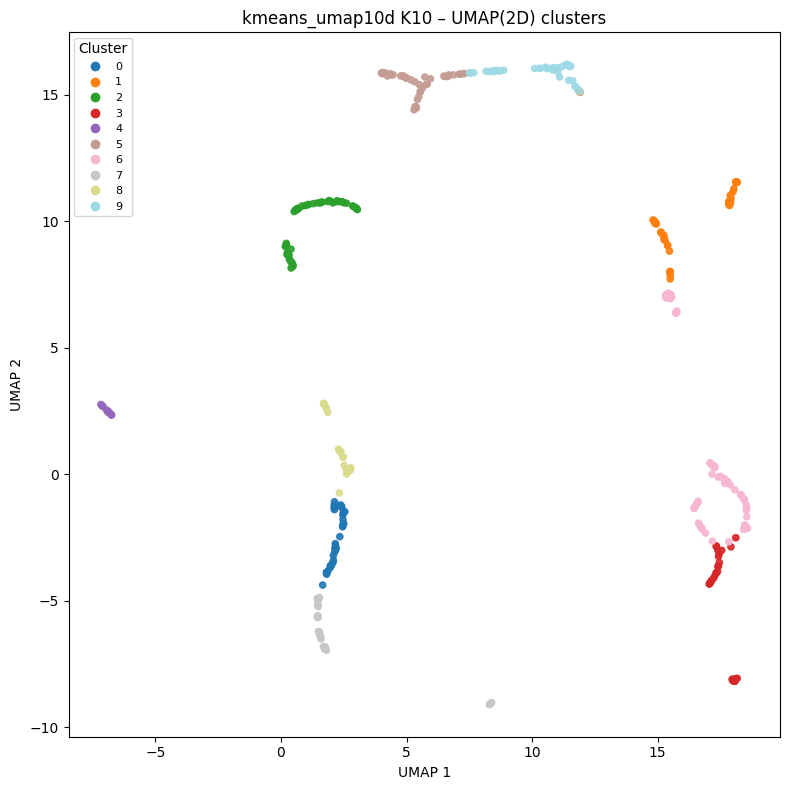

[kmeans_umap10d K10] Saved 2D UMAP clusters to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K10_umap2d_clusters.png


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[kmeans_umap10d K10] UMAP 3D embedding shape: (399, 3)


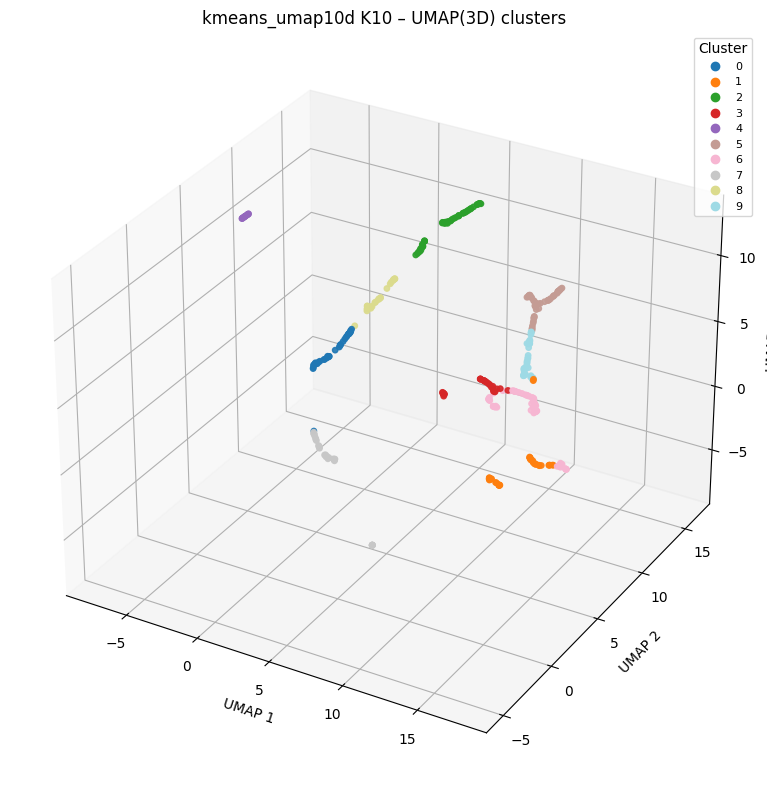

[kmeans_umap10d K10] Saved 3D UMAP clusters to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K10_umap3d_clusters.png


In [81]:
# Visual UMAP cluster plots (2D + 3D) for best KMeans on UMAP10D
save_umap_cluster_scatter_2d_3d(
    X_for_umap=X_for_clustering,          # here: X_umap_hd (10D)
    df_meta=df_meta,
    labels=best_kmeans_labels,
    base_dir=BEST_KMEANS_DIR,
    algo_tag="kmeans_umap10d",
    param_tag=f"K{best_K_kmeans}",
    n_neighbors=10,
    min_dist=0.09,
    random_state=RANDOM_STATE,
)


###  NEw version:

In [82]:
# from pathlib import Path
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.patches import Ellipse
# from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

# def save_umap_cluster_scatter_2d_3d(
#     X_for_umap,
#     df_meta,
#     labels,
#     base_dir: Path,
#     algo_tag: str,
#     param_tag: str,
#     n_neighbors: int = 30,
#     min_dist: float = 0.05,
#     random_state: int = 42,
# ):
#     """
#     1) Compute UMAP(2D) + draw:
#          - points colored by patient (patient_codes),
#          - edges colored by condition (edgecolors),
#          - per-cluster ellipses ('clouds') with IDs.
#     2) Compute UMAP(3D) + draw:
#          - points colored by patient_codes,
#          - edges by condition,
#          - cluster centroids with text labels,
#          - save several viewing angles to show depth better.
#     """

#     X_for_umap = np.asarray(X_for_umap)
#     labels = np.asarray(labels)

#     if X_for_umap.shape[0] != len(labels):
#         raise ValueError(f"X_for_umap rows ({X_for_umap.shape[0]}) != labels ({len(labels)})")
#     if len(df_meta) != len(labels):
#         raise ValueError(f"df_meta ({len(df_meta)}) != labels ({len(labels)})")

#     base_dir.mkdir(parents=True, exist_ok=True)

#     # ------------------------ UMAP 2D ------------------------
#     reducer_2d = umap.UMAP(
#         n_neighbors=n_neighbors,
#         min_dist=min_dist,
#         n_components=2,
#         metric="euclidean",
#         random_state=random_state,
#     )
#     emb2 = reducer_2d.fit_transform(X_for_umap)
#     print(f"[{algo_tag} {param_tag}] UMAP 2D embedding shape:", emb2.shape)

#     fig2d, ax2d = plt.subplots(figsize=(8, 8))

#     # Points: patient colors, condition edges
#     sc = ax2d.scatter(
#         emb2[:, 0],
#         emb2[:, 1],
#         c=patient_codes,       # global: patient-coded colors
#         cmap="tab20",
#         s=25,
#         alpha=0.9,
#         edgecolors=edgecolors, # global: condition edgecolors
#         linewidths=0.6,
#     )

#     ax2d.set_title(f"{algo_tag} {param_tag} – UMAP(2D) clusters", fontsize=12)
#     ax2d.set_xlabel("UMAP 1", fontsize=10)
#     ax2d.set_ylabel("UMAP 2", fontsize=10)

#     # Patient legend (color)
#     cmap_obj = sc.cmap
#     norm = plt.Normalize(vmin=patient_codes.min(), vmax=patient_codes.max())
#     patient_handles, patient_labels_list = [], []
#     for code, pid in enumerate(patient_uniques):
#         patient_handles.append(
#             plt.Line2D(
#                 [], [], marker="o", linestyle="",
#                 markersize=6,
#                 markerfacecolor=cmap_obj(norm(code)),
#                 markeredgecolor="black", linewidth=0,
#             )
#         )
#         patient_labels_list.append(pid)
#     leg_pat = ax2d.legend(
#         patient_handles,
#         patient_labels_list,
#         title="patient_id",
#         fontsize=7,
#         loc="best",
#     )
#     ax2d.add_artist(leg_pat)

#     # Condition legend (edge color)
#     cond_handles, cond_labels_list = [], []
#     for cond_name in cond_uniques:
#         cond_handles.append(
#             plt.Line2D(
#                 [], [], marker="o", linestyle="",
#                 markersize=6,
#                 markerfacecolor="lightgray",
#                 markeredgecolor=cond_edge_map.get(cond_name, "black"),
#                 linewidth=1.0,
#             )
#         )
#         cond_labels_list.append(cond_name)
#     ax2d.legend(
#         cond_handles,
#         cond_labels_list,
#         title="condition (edge color)",
#         fontsize=7,
#         loc="upper left",
#     )

#     # --- Cluster "clouds" as ellipses around points ---
#     unique_clusters = np.unique(labels)
#     for cl in unique_clusters:
#         mask = labels == cl
#         pts = emb2[mask]
#         if pts.shape[0] < 2:
#             # too few points for covariance; skip
#             continue

#         # mean + covariance of cluster in 2D
#         mean = pts.mean(axis=0)
#         cov = np.cov(pts, rowvar=False)

#         # eigen-decomposition
#         vals, vecs = np.linalg.eigh(cov)
#         order = np.argsort(vals)[::-1]
#         vals = vals[order]
#         vecs = vecs[:, order]

#         # ellipse angle
#         angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

#         # width/height = scaling factor * sqrt(eigenvalues)
#         # scale controls how "big" the cloud is
#         scale = 2.5
#         major_var = max(vals[0], 1e-9)
#         minor_var = max(vals[1], 1e-9)
#         width = 2 * scale * np.sqrt(major_var)
#         height = 2 * scale * np.sqrt(minor_var)

#         # color for hull only: use tab20 by cluster index
#         hull_color = plt.cm.tab20((int(cl) % 20) / 20.0)

#         ell = Ellipse(
#             xy=mean,
#             width=width,
#             height=height,
#             angle=angle,
#             facecolor=hull_color,
#             edgecolor=hull_color,
#             alpha=0.15,
#             linewidth=1.5,
#         )
#         ax2d.add_patch(ell)

#         # ---- cluster label OUTSIDE the cloud, along major axis ----
#         # major axis direction (unit vector)
#         major_vec = vecs[:, 0]
#         # semi-major axis length
#         a = scale * np.sqrt(major_var)
#         # put text a bit beyond the ellipse boundary
#         label_offset = 1.2 * a
#         label_pos = mean + major_vec * label_offset

#         ax2d.text(
#             label_pos[0], label_pos[1],
#             str(cl),
#             fontsize=8,
#             weight="bold",
#             ha="center",
#             va="center",
#             color=hull_color,   # same color as cloud
#         )


#     plt.tight_layout()
#     out_2d = base_dir / f"{algo_tag}_{param_tag}_umap2d_clustersv2_patientcolors_hulls.png"
#     plt.show()
#     fig2d.savefig(out_2d, dpi=150)
#     plt.close(fig2d)
#     print(f"[{algo_tag} {param_tag}] Saved 2D UMAP (patient-colored + cluster hulls) to: {out_2d}")

#     # ------------------------ UMAP 3D ------------------------
#     reducer_3d = umap.UMAP(
#         n_neighbors=n_neighbors,
#         min_dist=min_dist,
#         n_components=3,
#         metric="euclidean",
#         random_state=random_state,
#     )
#     emb3 = reducer_3d.fit_transform(X_for_umap)
#     print(f"[{algo_tag} {param_tag}] UMAP 3D embedding shape:", emb3.shape)

#     # We’ll make ONE 3D scatter and save multiple viewing angles.
#     fig3d = plt.figure(figsize=(8, 8))
#     ax3d = fig3d.add_subplot(111, projection="3d")

#     p3d = ax3d.scatter(
#         emb3[:, 0],
#         emb3[:, 1],
#         emb3[:, 2],
#         c=patient_codes,       # still patient colors
#         cmap="tab20",
#         s=15,
#         alpha=0.9,
#         edgecolors=edgecolors, # condition edges
#         linewidths=0.4,
#         depthshade=True,
#     )

#     ax3d.set_title(f"{algo_tag} {param_tag} – UMAP(3D) (patient colors)", fontsize=11)
#     ax3d.set_xlabel("UMAP 1", fontsize=9)
#     ax3d.set_ylabel("UMAP 2", fontsize=9)
#     ax3d.set_zlabel("UMAP 3", fontsize=9)

#     # Mark cluster centroids with text to help orientation
#     for cl in unique_clusters:
#         mask = labels == cl
#         pts3 = emb3[mask]
#         if pts3.shape[0] == 0:
#             continue
#         center3 = pts3.mean(axis=0)
#         ax3d.scatter(
#             center3[0], center3[1], center3[2],
#             s=50,
#             c="k",
#             marker="x",
#             linewidths=1.5,
#         )
#         ax3d.text(
#             center3[0], center3[1], center3[2],
#             str(cl),
#             fontsize=8,
#             ha="center",
#             va="center",
#             color="k",
#         )

#     # Several angles to make depth more obvious
#     angles = [
#         (20, 30),
#         (20, 120),
#         (20, 210),
#         (70, 45),
#     ]
#     for i, (elev, azim) in enumerate(angles, start=1):
#         ax3d.view_init(elev=elev, azim=azim)
#         plt.tight_layout()
#         plt.show()
#         out_3d = base_dir / f"{algo_tag}_{param_tag}_umap3d_clustersv2_view{i}.png"
#         fig3d.savefig(out_3d, dpi=150)
#         print(f"[{algo_tag} {param_tag}] Saved 3D UMAP view {i} to: {out_3d}")

#     plt.close(fig3d)


In [86]:
# save_umap_cluster_scatter_2d_3d(
#     X_for_umap=X_for_clustering,    # 10D UMAP space
#     df_meta=df_meta,
#     labels=best_kmeans_labels,
#     base_dir=BEST_KMEANS_DIR,
#     algo_tag="kmeans_umap10d",
#     param_tag=f"K{best_K_kmeans}",
#     n_neighbors=30,
#     min_dist=0.05,
#     random_state=RANDOM_STATE,
# )


In [90]:
# from matplotlib import animation
# from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)


# def save_umap3d_rotating_gifs(
#     emb3,
#     labels,
#     df_meta,
#     base_dir,
#     algo_tag: str,
#     param_tag: str,
#     init_elev: float = 20,
#     init_azim: float = 30,
# ):
#     """
#     Make two GIFs of a 3D embedding with patient colors + condition edges and
#     spherical 'cloud balls' around each cluster:

#       1) Rotate camera around z-axis (azimuth 0..360, elev fixed).
#       2) Rotate camera in elevation (0..360, azimuth fixed).

#     Parameters
#     ----------
#     emb3 : array, shape (n_samples, 3)
#         3D embedding (e.g. UMAP 3D).
#     labels : array, shape (n_samples,)
#         Cluster labels (e.g. best-K KMeans).
#     df_meta : DataFrame
#         Only used to check alignment.
#     base_dir : Path
#         Where to save GIFs.
#     algo_tag : str
#         E.g. 'kmeans_umap10d'.
#     param_tag : str
#         E.g. 'K13'.
#     init_elev, init_azim : float
#         Initial viewing angles for the camera.
#     """

#     emb3 = np.asarray(emb3)
#     labels = np.asarray(labels)

#     if emb3.shape[0] != len(labels):
#         raise ValueError(f"emb3 rows ({emb3.shape[0]}) != labels ({len(labels)})")
#     if len(df_meta) != len(labels):
#         raise ValueError(f"df_meta ({len(df_meta)}) != labels ({len(labels)})")

#     base_dir.mkdir(parents=True, exist_ok=True)

#     unique_clusters = np.unique(labels)

#     # ----- Helper: build a single 3D figure with points + cluster balls -----
#     def make_base_figure():
#         fig = plt.figure(figsize=(8, 8))
#         ax = fig.add_subplot(111, projection="3d")

#         # Scatter points: patient colors, condition edges
#         sc = ax.scatter(
#             emb3[:, 0],
#             emb3[:, 1],
#             emb3[:, 2],
#             c=patient_codes,
#             cmap="tab20",
#             s=15,
#             alpha=0.9,
#             edgecolors=edgecolors,
#             linewidths=0.4,
#             depthshade=True,
#         )

#         ax.set_title(f"{algo_tag} {param_tag} – UMAP(3D)", fontsize=11)
#         ax.set_xlabel("UMAP 1", fontsize=9)
#         ax.set_ylabel("UMAP 2", fontsize=9)
#         ax.set_zlabel("UMAP 3", fontsize=9)

#         # Patient legend
#         cmap_obj = sc.cmap
#         norm = plt.Normalize(vmin=patient_codes.min(), vmax=patient_codes.max())
#         patient_handles, patient_labels_list = [], []
#         for code, pid in enumerate(patient_uniques):
#             patient_handles.append(
#                 plt.Line2D(
#                     [], [], marker="o", linestyle="",
#                     markersize=6,
#                     markerfacecolor=cmap_obj(norm(code)),
#                     markeredgecolor="black",
#                     linewidth=0,
#                 )
#             )
#             patient_labels_list.append(pid)
#         leg_pat = ax.legend(
#             patient_handles,
#             patient_labels_list,
#             title="patient_id",
#             fontsize=7,
#             loc="best",
#         )
#         ax.add_artist(leg_pat)

#         # Condition legend (edge color)
#         cond_handles, cond_labels_list = [], []
#         for cond_name in cond_uniques:
#             cond_handles.append(
#                 plt.Line2D(
#                     [], [], marker="o", linestyle="",
#                     markersize=6,
#                     markerfacecolor="lightgray",
#                     markeredgecolor=cond_edge_map.get(cond_name, "black"),
#                     linewidth=1.0,
#                 )
#             )
#             cond_labels_list.append(cond_name)
#         ax.legend(
#             cond_handles,
#             cond_labels_list,
#             title="condition (edge color)",
#             fontsize=7,
#             loc="upper right",
#         )

#         # ---- Cluster 'cloud balls' (spheres) around each cluster ----
#         # Sphere parameterization grid (shared)
#         u = np.linspace(0, 2 * np.pi, 25)
#         v = np.linspace(0, np.pi, 15)

#         for cl in unique_clusters:
#             mask = labels == cl
#             pts = emb3[mask]
#             if pts.shape[0] == 0:
#                 continue

#             center = pts.mean(axis=0)
#             # radius ~ 1.5 * std distance from center (avoid zero)
#             dists = np.linalg.norm(pts - center, axis=1)
#             r = max(dists.std(), 1e-3) * 1.5

#             color = plt.cm.tab20((int(cl) % 20) / 20.0)

#             xs = center[0] + r * np.outer(np.cos(u), np.sin(v))
#             ys = center[1] + r * np.outer(np.sin(u), np.sin(v))
#             zs = center[2] + r * np.outer(np.ones_like(u), np.cos(v))

#             ax.plot_surface(
#                 xs,
#                 ys,
#                 zs,
#                 rstride=1,
#                 cstride=1,
#                 color=color,
#                 alpha=0.12,
#                 linewidth=0,
#                 antialiased=True,
#             )

#             # Label just outside the sphere in +z direction
#             label_pos = center + np.array([0.0, 0.0, r * 1.1])
#             ax.text(
#                 label_pos[0],
#                 label_pos[1],
#                 label_pos[2],
#                 str(cl),
#                 fontsize=9,
#                 weight="bold",
#                 ha="center",
#                 va="center",
#                 color=color,
#             )

#         # Set a nice initial view
#         ax.view_init(elev=init_elev, azim=init_azim)
#         return fig, ax

#     # ------------------------------------------------------------------
#     # 1) Rotate around z-axis: vary azimuth, fixed elevation
#     # ------------------------------------------------------------------
#     fig_z, ax_z = make_base_figure()

#     def update_azim(frame):
#         az = frame  # degrees
#         ax_z.view_init(elev=init_elev, azim=az)
#         return ax_z,

#     frames_z = np.linspace(0, 360, 120)  # 120 frames full turn

#     anim_z = animation.FuncAnimation(
#         fig_z,
#         update_azim,
#         frames=frames_z,
#         interval=50,
#         blit=False,
#     )

#     out_z = base_dir / f"{algo_tag}_{param_tag}_umap3d_rotate_z.gif"
#     # Requires pillow installed: `pip install pillow`
#     anim_z.save(out_z, writer="pillow", fps=20)
#     plt.close(fig_z)
#     print(f"[{algo_tag} {param_tag}] Saved rotating Z GIF to: {out_z}")

#     # ------------------------------------------------------------------
#     # 2) Rotate in elevation: vary elev, fixed azimuth
#     # ------------------------------------------------------------------
#     fig_e, ax_e = make_base_figure()

#     def update_elev(frame):
#         el = frame
#         ax_e.view_init(elev=el, azim=init_azim)
#         return ax_e,

#     frames_e = np.linspace(0, 360, 120)

#     anim_e = animation.FuncAnimation(
#         fig_e,
#         update_elev,
#         frames=frames_e,
#         interval=50,
#         blit=False,
#     )

#     out_e = base_dir / f"{algo_tag}_{param_tag}_umap3d_rotate_elev.gif"
#     anim_e.save(out_e, writer="pillow", fps=20)
#     plt.close(fig_e)
#     print(f"[{algo_tag} {param_tag}] Saved rotating elevation GIF to: {out_e}")


In [91]:
# # After you have X_for_clustering = X_umap_hd and best_kmeans_labels:

# # Compute a single UMAP(3D) for animation purposes
# reducer_3d_for_gif = umap.UMAP(
#     n_neighbors=30,
#     min_dist=0.05,
#     n_components=3,
#     metric="euclidean",
#     random_state=RANDOM_STATE,
# )
# emb3_for_gif = reducer_3d_for_gif.fit_transform(X_for_clustering)

# # Save rotating GIFs with cluster balls
# save_umap3d_rotating_gifs(
#     emb3=emb3_for_gif,
#     labels=best_kmeans_labels,
#     df_meta=df_meta,
#     base_dir=BEST_KMEANS_DIR,
#     algo_tag="kmeans_umap10d",
#     param_tag=f"K{best_K_kmeans}",
#     init_elev=20,
#     init_azim=30,
# )


### STATS


=== KMeans statistics on UMAP(10D) ===
     K     inertia  silhouette  n_clusters_found
0    6  462.908875    0.554595                 6
1    7  362.913391    0.530039                 7
2    8  301.476105    0.508820                 8
3    9  250.760330    0.504079                 9
4   10  203.158859    0.521344                10
5   11  171.289978    0.517134                11
6   12  153.006546    0.517935                12
7   13  136.440994    0.497065                13
8   14  122.480873    0.499097                14
9   15  110.595573    0.499520                15
10  16   96.355225    0.500573                16
11  17   86.839615    0.502431                17
12  18   78.394989    0.507303                18
13  19   72.696007    0.507811                19
14  20   65.686081    0.518379                20
15  21   60.475319    0.517274                21
16  22   55.274036    0.519538                22
17  23   51.902340    0.512875                23
18  24   48.313808    0.51273

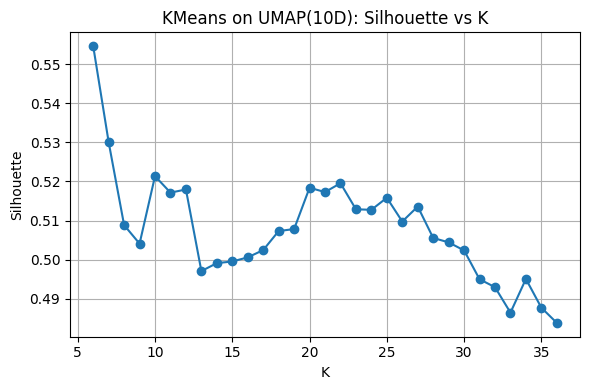

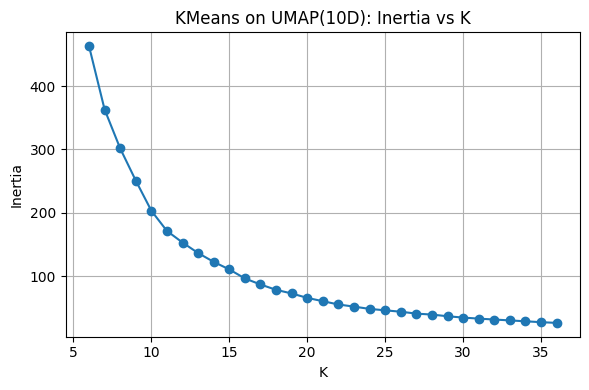

[KMeans UMAP10D] Best K over all: K=6 (sil=0.5546)


In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\n=== KMeans statistics on UMAP(10D) ===")

# 1) Build DataFrame
kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df = kmeans_results_df.sort_values("K")
print(kmeans_results_df[["K", "inertia", "silhouette", "n_clusters_found"]])

# 2) Silhouette vs K
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    kmeans_results_df["K"],
    kmeans_results_df["silhouette"],
    marker="o",
)
ax.set_xlabel("K")
ax.set_ylabel("Silhouette")
ax.set_title("KMeans on UMAP(10D): Silhouette vs K")
ax.grid(True)
plt.tight_layout()
plt.show()

# 3) Inertia vs K (elbow plot)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    kmeans_results_df["K"],
    kmeans_results_df["inertia"],
    marker="o",
)
ax.set_xlabel("K")
ax.set_ylabel("Inertia")
ax.set_title("KMeans on UMAP(10D): Inertia vs K")
ax.grid(True)
plt.tight_layout()
plt.show()

# 4) Quick summary: best K by silhouette (any K)
def safe_argmax_sil(df):
    if df["silhouette"].dropna().empty:
        return None, np.nan
    idx = df["silhouette"].idxmax()
    row = df.loc[idx]
    return int(row["K"]), float(row["silhouette"])

best_K_all, best_sil_all = safe_argmax_sil(kmeans_results_df)
if best_K_all is not None:
    print(f"[KMeans UMAP10D] Best K over all: K={best_K_all} (sil={best_sil_all:.4f})")
else:
    print("[KMeans UMAP10D] No valid silhouettes to choose best K.")


## Interpretability: of the UMAP extracted features


=== KMeans statistics on UMAP(10D) ===
     K     inertia  silhouette  n_clusters_found
0    6  462.908875    0.554595                 6
1    7  362.913391    0.530039                 7
2    8  301.476105    0.508820                 8
3    9  250.760330    0.504079                 9
4   10  203.158859    0.521344                10
5   11  171.289978    0.517134                11
6   12  153.006546    0.517935                12
7   13  136.440994    0.497065                13
8   14  122.480873    0.499097                14
9   15  110.595573    0.499520                15
10  16   96.355225    0.500573                16
11  17   86.839615    0.502431                17
12  18   78.394989    0.507303                18
13  19   72.696007    0.507811                19
14  20   65.686081    0.518379                20
15  21   60.475319    0.517274                21
16  22   55.274036    0.519538                22
17  23   51.902340    0.512875                23
18  24   48.313808    0.51273

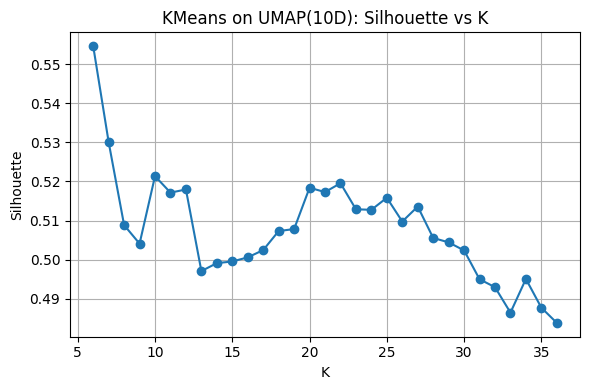

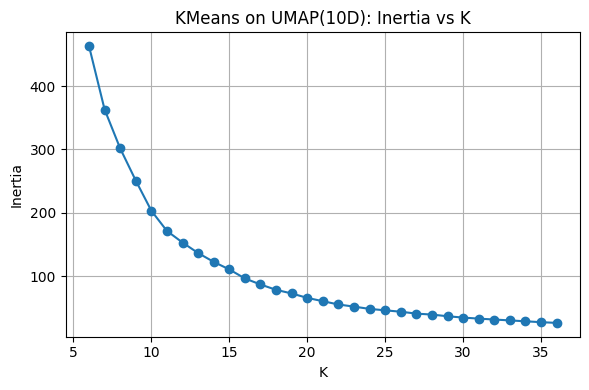

[KMeans UMAP10D] Best K over all (by silhouette): K=6 (sil=0.5546)

=== UMAP(2D) axes meaning: coloring by ERSP features ===


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


emb_axes shape: (399, 2)


NameError: name 'freq_norm' is not defined

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# ============================================================
# 1) KMeans statistics on UMAP(10D)
# ============================================================

print("\n=== KMeans statistics on UMAP(10D) ===")

kmeans_results_df = pd.DataFrame(kmeans_results).sort_values("K")
print(kmeans_results_df[["K", "inertia", "silhouette", "n_clusters_found"]])

# --- Silhouette vs K ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    kmeans_results_df["K"],
    kmeans_results_df["silhouette"],
    marker="o",
)
ax.set_xlabel("K")
ax.set_ylabel("Silhouette")
ax.set_title("KMeans on UMAP(10D): Silhouette vs K")
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Inertia vs K (elbow) ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    kmeans_results_df["K"],
    kmeans_results_df["inertia"],
    marker="o",
)
ax.set_xlabel("K")
ax.set_ylabel("Inertia")
ax.set_title("KMeans on UMAP(10D): Inertia vs K")
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Best K overall by silhouette ---
def safe_argmax_sil(df):
    if df["silhouette"].dropna().empty:
        return None, np.nan
    idx = df["silhouette"].idxmax()
    row = df.loc[idx]
    return int(row["K"]), float(row["silhouette"])

best_K_all, best_sil_all = safe_argmax_sil(kmeans_results_df)
if best_K_all is not None:
    print(f"[KMeans UMAP10D] Best K over all (by silhouette): K={best_K_all} (sil={best_sil_all:.4f})")
else:
    print("[KMeans UMAP10D] No valid silhouettes to choose best K.")


# ============================================================
# 2) UMAP(2D) axes meaning: color by ERSP/shape features
# ============================================================

print("\n=== UMAP(2D) axes meaning: coloring by ERSP features ===")

# We embed the 10D UMAP space (X_umap_hd) down to 2D for visualization
RANDOM_STATE = 42
X_for_clustering = X_umap_hd  # already defined in your pipeline

umap_axes_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    n_components=2,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
emb_axes = umap_axes_model.fit_transform(X_for_clustering)
print("emb_axes shape:", emb_axes.shape)

# --- Compute center_time_norm and center_freq_norm per electrode ---
center_freq_norm_list = []
center_time_norm_list = []

for arr in ersp_list:
    # arr: (N_FREQ, N_TIME)
    vals = np.abs(arr.astype(np.float64))
    total = vals.sum()
    if total > 0:
        cf = (vals * freq_norm[:, None]).sum() / total
        ct = (vals * time_norm[None, :]).sum() / total
    else:
        cf = np.nan
        ct = np.nan
    center_freq_norm_list.append(cf)
    center_time_norm_list.append(ct)

df_meta["center_freq_norm"] = center_freq_norm_list
df_meta["center_time_norm"] = center_time_norm_list

# --- 4-panel figure: prop_above_pos, prop_below_neg, center_time_norm, center_freq_norm ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

plots_info = [
    ("prop_above_pos", "Prop > +thr (pos)", df_meta["prop_above_pos"]),
    ("prop_below_neg", "Prop < -thr (neg)", df_meta["prop_below_neg"]),
    ("center_time_norm", "Center time (norm)", df_meta["center_time_norm"]),
    ("center_freq_norm", "Center freq (norm)", df_meta["center_freq_norm"]),
]

for ax, (col_name, title, values) in zip(axes, plots_info):
    sc = ax.scatter(
        emb_axes[:, 0],
        emb_axes[:, 1],
        c=values,
        cmap="viridis",
        s=15,
        alpha=0.9,
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("UMAP 1", fontsize=8)
    ax.set_ylabel("UMAP 2", fontsize=8)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.ax.tick_params(labelsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("UMAP(2D) of UMAP10D embedding – colored by ERSP/shape features", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- High-activity flag ---
fig, ax = plt.subplots(figsize=(5, 4))
colors_ha = df_meta["high_activity"].map({True: "red", False: "gray"}).to_numpy()
ax.scatter(
    emb_axes[:, 0],
    emb_axes[:, 1],
    c=colors_ha,
    s=15,
    alpha=0.9,
)
ax.set_title("UMAP(2D) – High-activity (red) vs normal/low (gray)", fontsize=11)
ax.set_xlabel("UMAP 1", fontsize=9)
ax.set_ylabel("UMAP 2", fontsize=9)
plt.tight_layout()
plt.show()


# ============================================================
# 3) Cluster composition sanity checks (for best KMeans on UMAP10D)
# ============================================================

print("\n=== Cluster composition sanity checks ===")

# Try to reuse your best_K_kmeans / best_kmeans_labels (restricted 8<K<20),
# otherwise fall back to best_K_all (global best) from kmeans_results_df.
try:
    best_K = best_K_kmeans
    best_labels = best_kmeans_labels
    print(f"Using existing best_K_kmeans={best_K}")
except NameError:
    if best_K_all is None:
        raise RuntimeError("No best K found and best_K_kmeans not defined.")
    best_K = best_K_all
    best_labels = kmeans_label_dict[best_K]
    print(f"Using best_K_all={best_K} from kmeans_results_df")

df_meta["cluster_kmeans_umap10d_bestK"] = best_labels

cluster_ids = sorted(np.unique(best_labels))

# --- Basic per-cluster stats ---
cluster_sizes = []
uniq_patients_per_cluster = []
frac_high_activity = []

for c in cluster_ids:
    df_c = df_meta[df_meta["cluster_kmeans_umap10d_bestK"] == c]
    cluster_sizes.append(len(df_c))
    uniq_patients_per_cluster.append(df_c["patient_id"].nunique())
    if len(df_c) > 0:
        frac_high_activity.append(df_c["high_activity"].mean())
    else:
        frac_high_activity.append(np.nan)

# A) Bar plots: size, unique patients, fraction high-activity
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

x = np.arange(len(cluster_ids))

axes[0].bar(x, cluster_sizes)
axes[0].set_ylabel("n samples")
axes[0].set_title(f"KMeans UMAP10D (K={best_K}) – cluster sizes")

axes[1].bar(x, uniq_patients_per_cluster)
axes[1].set_ylabel("# unique patients")
axes[1].set_title("Unique patients per cluster")

axes[2].bar(x, frac_high_activity)
axes[2].set_ylabel("Frac high_activity")
axes[2].set_xlabel("Cluster ID")
axes[2].set_title("Fraction of high-activity electrodes per cluster")
axes[2].set_xticks(x)
axes[2].set_xticklabels(cluster_ids)

for ax in axes:
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# B) Condition composition (stacked bar)
conditions = sorted(df_meta["condition"].unique())
condition_colors = {
    cond: color for cond, color in zip(
        conditions,
        ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    )
}

cond_fracs_per_cluster = {cond: [] for cond in conditions}

for c in cluster_ids:
    df_c = df_meta[df_meta["cluster_kmeans_umap10d_bestK"] == c]
    total_c = len(df_c)
    for cond in conditions:
        if total_c > 0:
            frac = (df_c["condition"] == cond).mean()
        else:
            frac = 0.0
        cond_fracs_per_cluster[cond].append(frac)

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(cluster_ids))

for cond in conditions:
    fracs = np.array(cond_fracs_per_cluster[cond])
    ax.bar(
        x,
        fracs,
        bottom=bottom,
        color=condition_colors.get(cond, "gray"),
        edgecolor="none",
        label=cond,
    )
    bottom += fracs

ax.set_xticks(x)
ax.set_xticklabels(cluster_ids)
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Fraction")
ax.set_title(f"KMeans UMAP10D (K={best_K}) – condition composition per cluster")
ax.legend(title="Condition", fontsize=8)
ax.set_ylim(0, 1.0)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# ============================================================
# 4) KMeans stability check (same K, different random_state)
# ============================================================

print("\n=== KMeans stability check (Adjusted Rand Index) ===")

kmeans_stable = KMeans(
    n_clusters=best_K,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE + 123,  # different seed
    verbose=0,
)
kmeans_stable.fit(X_for_clustering)
labels_stable = kmeans_stable.labels_

ari = adjusted_rand_score(best_labels, labels_stable)
print(
    f"Stability for K={best_K}: Adjusted Rand Index (original vs new KMeans) = {ari:.4f}"
)



print("\n=== KMeans stability check (Adjusted Rand Index) V2 ===")

kmeans_stable = KMeans(
    n_clusters=best_K,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE + 300,  # different seed
    verbose=0,
)
kmeans_stable.fit(X_for_clustering)
labels_stable = kmeans_stable.labels_

ari = adjusted_rand_score(best_labels, labels_stable)
print(
    f"Stability for K={best_K}: Adjusted Rand Index (original vs new KMeans) = {ari:.4f}"
)


# GMM


=== GMM sweep on UMAP(10D) features ===

--- GMM on UMAP10D with K=6 ---
Cluster counts      : {0: 65, 1: 55, 2: 58, 3: 85, 4: 88, 5: 48}
Silhouette          : 0.5292869210243225
BIC                 : -1332.428581395542
AIC                 : -1831.048758506775
Neg avg log-likely  : -2.6064625
[gmm_umap10d K6] Saved cluster cards to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\gmm_umap10d_cluster_cards\gmm_umap10d_K6_cluster_cards.png

--- GMM on UMAP10D with K=7 ---
Cluster counts      : {0: 45, 1: 58, 2: 51, 3: 55, 4: 77, 5: 48, 6: 65}
Silhouette          : 0.5087527632713318
BIC                 : -1949.8211792232523
AIC                 : -2532.2095460891724
Neg avg log-likely  : -3.540039
[gmm_umap10d K7] Saved cluster cards to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\gmm_umap10d_cluster_cards\gmm_umap10d_K7_cluster_cards.png

--- GMM on UMAP10D with K=8 ---
Cluster counts

C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[gmm_umap10d K9] UMAP 2D embedding shape: (399, 2)
save_umap_cluster_scatter_2d_3d not defined; skipping 2D/3D PNGs.


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


save_umap3d_rotating_gifs not defined; skipping 3D GIFs.

=== GMM stability check (Adjusted Rand Index) ===
GMM stability for K=9: Adjusted Rand Index (original vs new GMM) = 0.8769

Saved df_meta with GMM-UMAP10D best-K cluster column to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\df_meta_with_gmm_umap10d_bestK.tsv


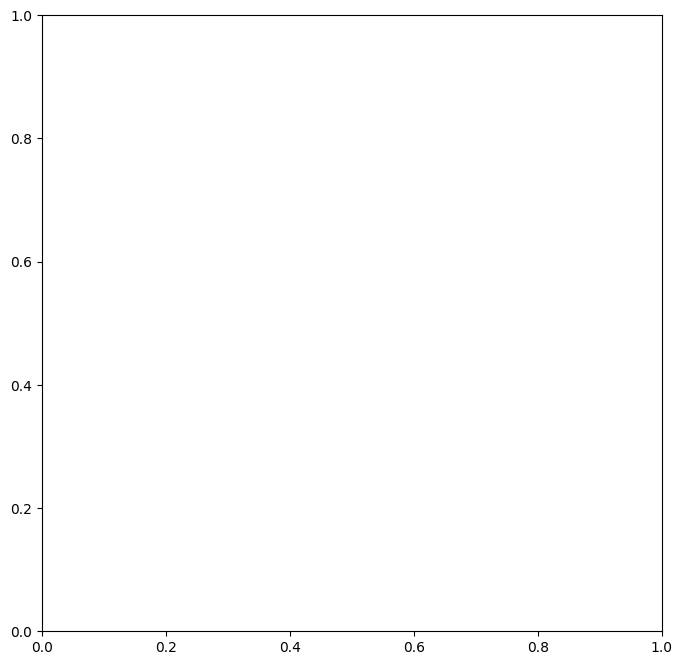

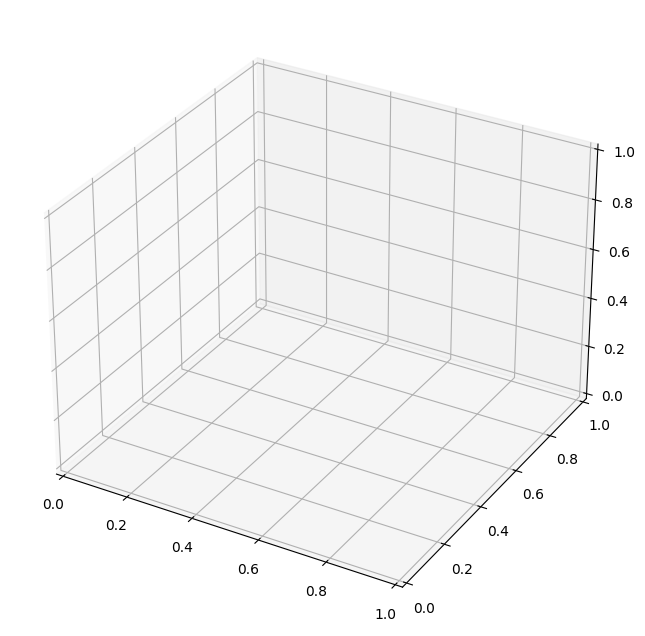

In [103]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap

# ============================================================
# 1) Paths for GMM-on-UMAP10D outputs
# ============================================================

FIGURES_GMM_UMAP10D_CLUSTER_CARDS_DIR = (
    ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/gmm_umap10d_cluster_cards"
)
FIGURES_GMM_UMAP10D_CLUSTER_CARDS_DIR.mkdir(parents=True, exist_ok=True)

BEST_GMM_UMAP10D_DIR = (
    ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/gmm_umap10d_bestK"
)
BEST_GMM_UMAP10D_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2) GMM sweep on UMAP(10D) features
# ============================================================

print("\n=== GMM sweep on UMAP(10D) features ===")

# 10D space we cluster on (same as KMeans)
X_for_clustering = X_umap_hd

GMM_K_RANGE = [6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
               21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36]

gmm_results = []
gmm_label_dict = {}

PLOT_GMM_CLUSTER_CARDS = True  # set False if you want to skip PNGs

for K in GMM_K_RANGE:
    print(f"\n--- GMM on UMAP10D with K={K} ---")
    gmm = GaussianMixture(
        n_components=K,
        covariance_type="full",   # change to 'full' if you prefer
        random_state=RANDOM_STATE,
        n_init=5,
        max_iter=300,
    )

    gmm.fit(X_for_clustering)
    labels = gmm.predict(X_for_clustering)

    # Silhouette
    unique_labels, counts = np.unique(labels, return_counts=True)
    if len(unique_labels) > 1:
        sil = silhouette_score(X_for_clustering, labels)
    else:
        sil = np.nan

    # BIC/AIC + a simple "inertia-like" score (negative avg log-likelihood)
    bic = gmm.bic(X_for_clustering)
    aic = gmm.aic(X_for_clustering)
    neg_log_like = -gmm.lower_bound_   # avg negative log-likelihood per sample

    print("Cluster counts      :", dict(zip(unique_labels, counts)))
    print("Silhouette          :", sil)
    print("BIC                 :", bic)
    print("AIC                 :", aic)
    print("Neg avg log-likely  :", neg_log_like)

    gmm_results.append({
        "algo": "gmm_umap10d",
        "K": K,
        "silhouette": sil,
        "bic": bic,
        "aic": aic,
        "neg_log_like": neg_log_like,
        "n_clusters_found": len(unique_labels),
    })
    gmm_label_dict[K] = labels.copy()

    # Cluster cards (condition stripe + mean ERSP)
    if PLOT_GMM_CLUSTER_CARDS:
        try:
            save_cluster_cards_generic(
                df_meta=df_meta,
                labels=labels,
                ersp_list=ersp_list,
                algo_tag="gmm_umap10d",
                param_tag=f"K{K}",
                out_dir=FIGURES_GMM_UMAP10D_CLUSTER_CARDS_DIR,
                n_freq=N_FREQ,
                n_time=N_TIME,
            )
        except NameError:
            print("save_cluster_cards_generic is not defined; skipping cluster cards.")

print("\nGMM sweep on UMAP10D finished.")

# ============================================================
# 3) Select best K by silhouette in (8, 20)
# ============================================================

def select_best_k_by_silhouette(results_list, k_key="K", sil_key="silhouette"):
    """
    results_list: list of dicts with keys [k_key, sil_key].
    Returns (best_K, best_sil) or (None, None) if no valid entries
    with 8 < K < 20.
    """
    candidates = [
        (r[k_key], r.get(sil_key, np.nan))
        for r in results_list
        if (r[k_key] > 8 and r[k_key] < 20 and not np.isnan(r.get(sil_key, np.nan)))
    ]
    if not candidates:
        return None, None
    best_K, best_sil = max(candidates, key=lambda t: t[1])
    return best_K, best_sil

print("\n=== Selecting best K by silhouette for GMM on UMAP10D (8 < K < 20) ===")

gmm_results_df = pd.DataFrame(gmm_results).sort_values("K")
best_K_gmm, best_sil_gmm = select_best_k_by_silhouette(
    gmm_results,
    k_key="K",
    sil_key="silhouette",
)

if best_K_gmm is not None:
    print(f"[GMM UMAP10D] Best K in (8,20): K={best_K_gmm} (sil={best_sil_gmm:.4f})")
    best_gmm_labels = gmm_label_dict[best_K_gmm]

    # Attach labels to df_meta
    df_meta["cluster_gmm_umap10d_bestK"] = best_gmm_labels

    # Save labels to disk
    np.save(
        BEST_GMM_UMAP10D_DIR / f"gmm_umap10d_bestK_labels_K{best_K_gmm}.npy",
        best_gmm_labels,
    )
    print(
        "[GMM UMAP10D] Saved best-K labels to:",
        BEST_GMM_UMAP10D_DIR / f"gmm_umap10d_bestK_labels_K{best_K_gmm}.npy",
    )

    # Export per-cluster images + centroids, if helper exists
    try:
        export_best_cluster_images(
            df_meta=df_meta,
            labels=best_gmm_labels,
            ersp_list=ersp_list,
            algo_name="gmm_umap10d",
            param_tag=f"K{best_K_gmm}",
            base_dir=BEST_GMM_UMAP10D_DIR,
            image_suffix=".png",
            save_centroid_npy=True,
        )
    except NameError:
        print("export_best_cluster_images not defined; skipping image export.")

    # ========================================================
    # 4) UMAP(2D/3D) cluster visualizations for best GMM
    # ========================================================

    # 2D hulls + 3D multi-view PNGs
    try:
        save_umap_cluster_scatter_2d_3d(
            X_for_umap=X_for_clustering,
            df_meta=df_meta,
            labels=best_gmm_labels,
            base_dir=BEST_GMM_UMAP10D_DIR,
            algo_tag="gmm_umap10d",
            param_tag=f"K{best_K_gmm}",
            n_neighbors=30,
            min_dist=0.05,
            random_state=RANDOM_STATE,
        )
    except NameError:
        print("save_umap_cluster_scatter_2d_3d not defined; skipping 2D/3D PNGs.")

    # 3D rotating GIFs (cluster balls)
    try:
        # Compute a single 3D UMAP just for GIFs
        reducer_3d_for_gif = umap.UMAP(
            n_neighbors=30,
            min_dist=0.05,
            n_components=3,
            metric="euclidean",
            random_state=RANDOM_STATE,
        )
        emb3_for_gif = reducer_3d_for_gif.fit_transform(X_for_clustering)

        save_umap3d_rotating_gifs(
            emb3=emb3_for_gif,
            labels=best_gmm_labels,
            df_meta=df_meta,
            base_dir=BEST_GMM_UMAP10D_DIR,
            algo_tag="gmm_umap24d",
            param_tag=f"K{best_K_gmm}",
            init_elev=20,
            init_azim=30,
        )
    except NameError:
        print("save_umap3d_rotating_gifs not defined; skipping 3D GIFs.")
else:
    print("[GMM UMAP10D] No valid K in (8,20) with non-NaN silhouette.")


# ============================================================
# 5) GMM stability check (Adjusted Rand Index) for best_K_gmm
# ============================================================

if best_K_gmm is not None:
    print("\n=== GMM stability check (Adjusted Rand Index) ===")

    labels_original = best_gmm_labels

    gmm_stable = GaussianMixture(
        n_components=best_K_gmm,
        covariance_type="diag",  # keep in sync with above
        random_state=RANDOM_STATE + 123,
        n_init=5,
        max_iter=300,
    )
    gmm_stable.fit(X_for_clustering)
    labels_stable = gmm_stable.predict(X_for_clustering)

    ari_gmm = adjusted_rand_score(labels_original, labels_stable)
    print(
        f"GMM stability for K={best_K_gmm}: "
        f"Adjusted Rand Index (original vs new GMM) = {ari_gmm:.4f}"
    )


# ============================================================
# 6) Save df_meta with GMM best-K column
# ============================================================

out_tsv_gmm = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/df_meta_with_gmm_umap10d_bestK.tsv"
df_meta.to_csv(out_tsv_gmm, sep="\t", index=False)
print("\nSaved df_meta with GMM-UMAP10D best-K cluster column to:", out_tsv_gmm)



=== GMM statistics on UMAP(10D) ===
Columns in gmm_results_df: ['algo', 'K', 'silhouette', 'bic', 'aic', 'neg_log_like', 'n_clusters_found']
     K  silhouette          bic          aic  n_clusters_found
0    6    0.529287 -1332.428581 -1831.048759                 6
1    7    0.508753 -1949.821179 -2532.209546                 7
2    8    0.522059 -2490.104102 -3156.260658                 8
3    9    0.517821 -3058.197801 -3808.122547                 9
4   10    0.504558 -3536.544506 -4370.237442                10
5   11    0.498771 -4019.005731 -4936.466857                11
6   12    0.487297 -4176.447268 -5177.676583                12
7   13    0.485703 -4382.476138 -5467.473643                13
8   14    0.461149 -4439.412350 -5608.178045                14
9   15    0.510386 -4653.441190 -5905.975075                15
10  16    0.509772 -4821.265487 -6157.567562                16
11  17    0.496412 -4941.917210 -6361.987474                17
12  18    0.499663 -5128.412669 -6632.2

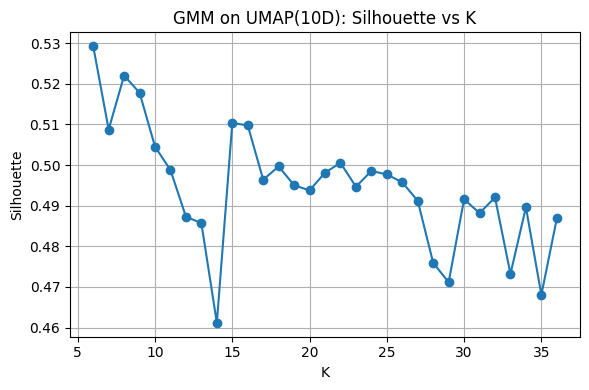

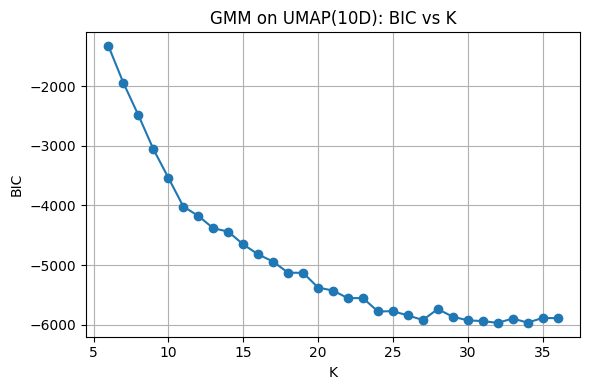

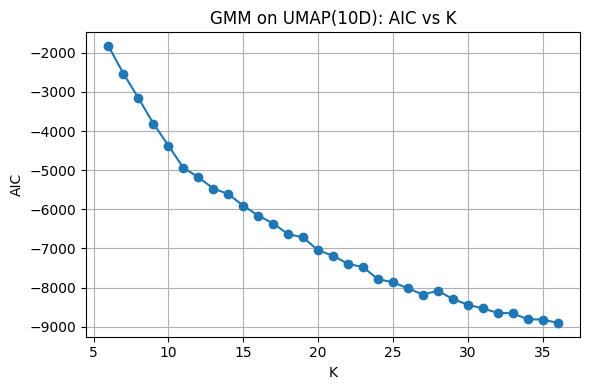

[GMM UMAP10D] Best K over all (by silhouette): K=6 (sil=0.5293)
Using existing best_K_gmm=9

=== GMM stability check (Adjusted Rand Index) ===
GMM stability for K=9: Adjusted Rand Index (original vs new GMM) = 0.8769


In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# ============================================================
# GMM statistics on UMAP(10D)
# ============================================================

print("\n=== GMM statistics on UMAP(10D) ===")

gmm_results_df = pd.DataFrame(gmm_results).sort_values("K")
print("Columns in gmm_results_df:", gmm_results_df.columns.tolist())

# Print a compact table of the most relevant columns if they exist
cols_to_show = ["K", "silhouette", "bic", "aic", "n_clusters_found"]
cols_to_show = [c for c in cols_to_show if c in gmm_results_df.columns]
print(gmm_results_df[cols_to_show])

# 1) Silhouette vs K
if "silhouette" in gmm_results_df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(
        gmm_results_df["K"],
        gmm_results_df["silhouette"],
        marker="o",
    )
    ax.set_xlabel("K")
    ax.set_ylabel("Silhouette")
    ax.set_title("GMM on UMAP(10D): Silhouette vs K")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No 'silhouette' column in gmm_results_df – skipping Silhouette vs K plot.")

# 2) BIC vs K (if available)
if "bic" in gmm_results_df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(
        gmm_results_df["K"],
        gmm_results_df["bic"],
        marker="o",
    )
    ax.set_xlabel("K")
    ax.set_ylabel("BIC")
    ax.set_title("GMM on UMAP(10D): BIC vs K")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No 'bic' column in gmm_results_df – skipping BIC vs K plot.")

# 3) AIC vs K (if available)
if "aic" in gmm_results_df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(
        gmm_results_df["K"],
        gmm_results_df["aic"],
        marker="o",
    )
    ax.set_xlabel("K")
    ax.set_ylabel("AIC")
    ax.set_title("GMM on UMAP(10D): AIC vs K")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No 'aic' column in gmm_results_df – skipping AIC vs K plot.")

# 4) Best K overall by silhouette
def safe_argmax_sil(df):
    if "silhouette" not in df.columns:
        return None, np.nan
    if df["silhouette"].dropna().empty:
        return None, np.nan
    idx = df["silhouette"].idxmax()
    row = df.loc[idx]
    return int(row["K"]), float(row["silhouette"])

best_K_gmm_all, best_sil_gmm_all = safe_argmax_sil(gmm_results_df)
if best_K_gmm_all is not None:
    print(f"[GMM UMAP10D] Best K over all (by silhouette): K={best_K_gmm_all} (sil={best_sil_gmm_all:.4f})")
else:
    print("[GMM UMAP10D] No valid silhouettes to choose best K.")

# If you already had a best_K_gmm from your 8<K<20 selection, reuse it;
# otherwise fall back to best_K_gmm_all
try:
    best_K_gmm = best_K_gmm  # noqa: F821 (if already defined earlier)
    best_gmm_labels = best_gmm_labels
    print(f"Using existing best_K_gmm={best_K_gmm}")
except NameError:
    if best_K_gmm_all is None:
        raise RuntimeError("No best K for GMM found.")
    best_K_gmm = best_K_gmm_all
    best_gmm_labels = gmm_label_dict[best_K_gmm]
    print(f"Using best_K_gmm_all={best_K_gmm} from gmm_results_df")

# Attach labels to df_meta (for later interpretation if you want)
df_meta["cluster_gmm_umap10d_bestK"] = best_gmm_labels

# ============================================================
# GMM stability check (Adjusted Rand Index)
# ============================================================

print("\n=== GMM stability check (Adjusted Rand Index) ===")

X_for_clustering = X_umap_hd  # same as for KMeans

# Original labels come from your previous GMM sweep (gmm_label_dict)
labels_original = best_gmm_labels

# Re-fit a new GMM with same K but different random_state
gmm_stable = GaussianMixture(
    n_components=best_K_gmm,
    covariance_type="diag",  # adjust if you used 'full' or another type
    random_state=RANDOM_STATE + 123,
    n_init=5,
    max_iter=300,
)
gmm_stable.fit(X_for_clustering)
labels_stable = gmm_stable.predict(X_for_clustering)

ari_gmm = adjusted_rand_score(labels_original, labels_stable)
print(
    f"GMM stability for K={best_K_gmm}: "
    f"Adjusted Rand Index (original vs new GMM) = {ari_gmm:.4f}"
)



KMeans results (K, silhouette):
     K  silhouette
0    6    0.554595
1    7    0.530039
2    8    0.508820
3    9    0.504079
4   10    0.521344
5   11    0.517134
6   12    0.517935
7   13    0.497065
8   14    0.499097
9   15    0.499520
10  16    0.500573
11  17    0.502431
12  18    0.507303
13  19    0.507811
14  20    0.518379
15  21    0.517274
16  22    0.519538
17  23    0.512875
18  24    0.512732
19  25    0.515819
20  26    0.509739
21  27    0.513570
22  28    0.505542
23  29    0.504408
24  30    0.502347
25  31    0.494981
26  32    0.492942
27  33    0.486439
28  34    0.495047
29  35    0.487694
30  36    0.483813

GMM results (K, silhouette):
     K  silhouette
0    6    0.529287
1    7    0.508753
2    8    0.522059
3    9    0.517821
4   10    0.504558
5   11    0.498771
6   12    0.487297
7   13    0.485703
8   14    0.461149
9   15    0.510386
10  16    0.509772
11  17    0.496412
12  18    0.499663
13  19    0.495063
14  20    0.493767
15  21    0.498139
16  22

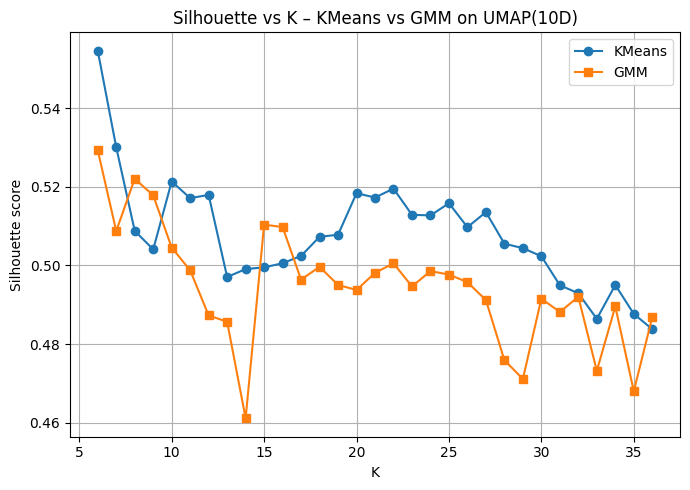

[KMeans] Best K=6, silhouette=0.5546
[GMM] Best K=6, silhouette=0.5293


In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming these already exist from your sweeps:
# kmeans_results, gmm_results

# ----------------------------
# Build DataFrames
# ----------------------------
kmeans_results_df = pd.DataFrame(kmeans_results).sort_values("K")
gmm_results_df    = pd.DataFrame(gmm_results).sort_values("K")

print("\nKMeans results (K, silhouette):")
print(kmeans_results_df[["K", "silhouette"]])

print("\nGMM results (K, silhouette):")
print(gmm_results_df[["K", "silhouette"]])

# ----------------------------
# Silhouette vs K (combined)
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

if "silhouette" in kmeans_results_df.columns:
    ax.plot(
        kmeans_results_df["K"],
        kmeans_results_df["silhouette"],
        marker="o",
        label="KMeans",
    )

if "silhouette" in gmm_results_df.columns:
    ax.plot(
        gmm_results_df["K"],
        gmm_results_df["silhouette"],
        marker="s",
        label="GMM",
    )

ax.set_xlabel("K")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette vs K – KMeans vs GMM on UMAP(10D)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Print best K per algorithm
# ----------------------------
def best_K_by_sil(df, name):
    if "silhouette" not in df.columns or df["silhouette"].dropna().empty:
        print(f"[{name}] No valid silhouettes.")
        return
    idx = df["silhouette"].idxmax()
    row = df.loc[idx]
    print(f"[{name}] Best K={int(row['K'])}, silhouette={row['silhouette']:.4f}")

best_K_by_sil(kmeans_results_df, "KMeans")
best_K_by_sil(gmm_results_df, "GMM")


X_for_clustering shape: (399, 10)
[KMeans] Using existing best_K_kmeans=10
[GMM] Using existing best_K_gmm=9

=== OPTION 1: Multi-seed stability (KMeans & GMM) ===

[KMeans] Multi-seed stability at K=10, 10 seeds
KMeans ARI matrix (first 3x3):
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
KMeans multi-seed ARI mean=0.9506, std=0.0414


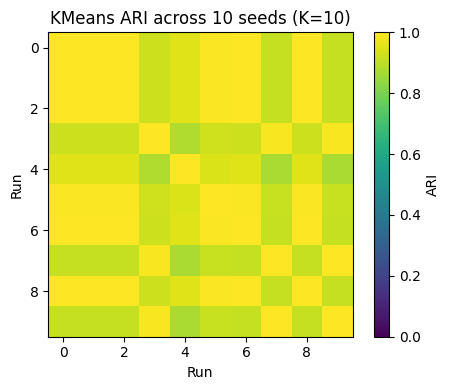

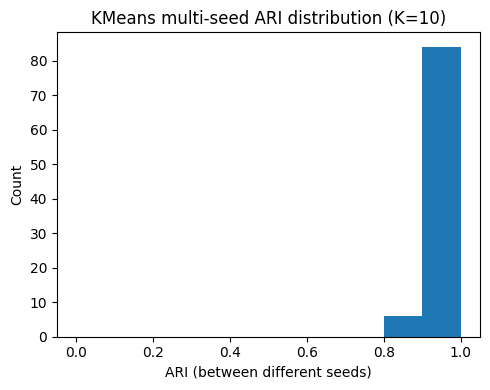


[GMM] Multi-seed stability at K=9, 10 seeds
GMM ARI matrix (first 3x3):
[[1.         0.87657151 0.87169136]
 [0.87657151 1.         0.99481198]
 [0.87169136 0.99481198 1.        ]]
GMM multi-seed ARI mean=0.8800, std=0.0694


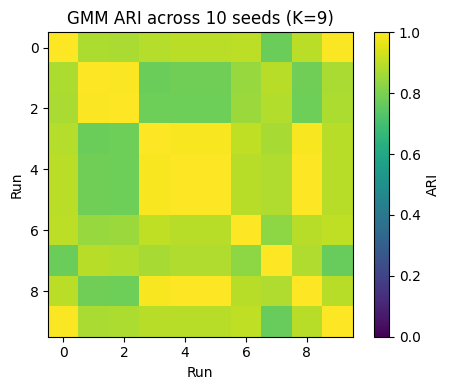

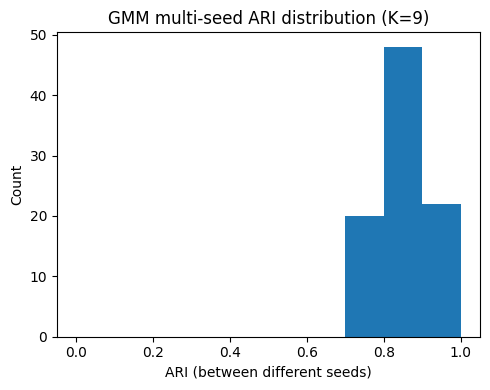


=== OPTION 2: Bootstrap/subsample stability (KMeans & GMM) ===
Using 20 runs, each with 319/399 samples (with replacement).

[KMeans] Bootstrap-like stability at K=10
KMeans bootstrap ARI matrix (first 3x3):
[[1.         0.71136694 0.80680647]
 [0.71136694 1.         0.73088457]
 [0.80680647 0.73088457 1.        ]]
KMeans bootstrap ARI mean=0.7638, std=0.0745


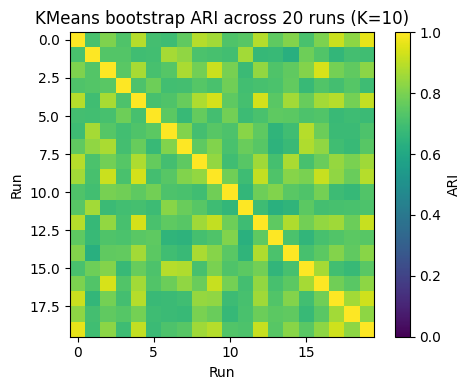

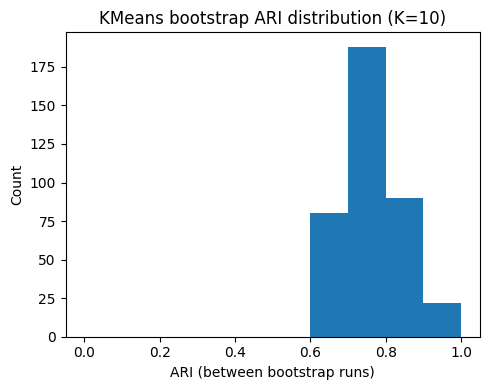


[GMM] Bootstrap-like stability at K=9
GMM bootstrap ARI matrix (first 3x3):
[[1.         0.64824694 0.71694891]
 [0.64824694 1.         0.77456027]
 [0.71694891 0.77456027 1.        ]]
GMM bootstrap ARI mean=0.7511, std=0.0794


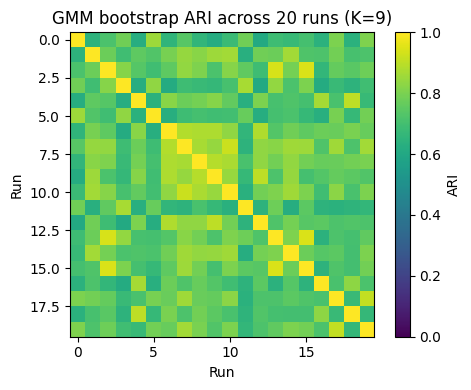

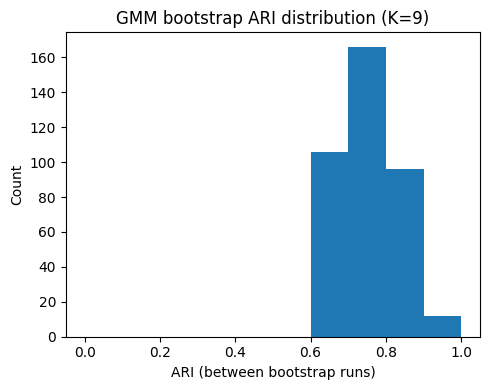

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

# ============================================================
# CONFIG
# ============================================================
np.shape(X_umap_hd)
X_for_clustering = X_umap_hd  # UMAP(10D) space
n_samples = X_for_clustering.shape[0]

N_SEEDS = 10         # Option 1: number of random seeds per algo (multi-seed)
N_BOOT = 20          # Option 2: number of bootstrap/subsample runs
BOOT_FRACTION = 0.8  # fraction of samples per bootstrap run

print("X_for_clustering shape:", X_for_clustering.shape)

# ============================================================
# Helper: get best K by silhouette from results list
# ============================================================

def best_K_by_silhouette_from_results(results, k_key="K", sil_key="silhouette"):
    if not results:
        return None, np.nan
    df = pd.DataFrame(results)
    if sil_key not in df.columns:
        return None, np.nan
    if df[sil_key].dropna().empty:
        return None, np.nan
    idx = df[sil_key].idxmax()
    row = df.loc[idx]
    return int(row[k_key]), float(row[sil_key])


# ============================================================
# Determine best K for KMeans and GMM if not already defined
# ============================================================

# ---- KMeans best K ----
try:
    _ = best_K_kmeans  # noqa: F821
    _ = best_kmeans_labels
    print(f"[KMeans] Using existing best_K_kmeans={best_K_kmeans}")
except NameError:
    best_K_kmeans, best_sil_kmeans = best_K_by_silhouette_from_results(
        kmeans_results, k_key="K", sil_key="silhouette"
    )
    if best_K_kmeans is None:
        raise RuntimeError("Could not determine best_K_kmeans from kmeans_results.")
    print(f"[KMeans] Inferred best_K_kmeans={best_K_kmeans} (sil={best_sil_kmeans:.4f})")
    best_kmeans_labels = kmeans_label_dict[best_K_kmeans]

# ---- GMM best K ----
try:
    _ = best_K_gmm  # noqa: F821
    _ = best_gmm_labels
    print(f"[GMM] Using existing best_K_gmm={best_K_gmm}")
except NameError:
    best_K_gmm, best_sil_gmm = best_K_by_silhouette_from_results(
        gmm_results, k_key="K", sil_key="silhouette"
    )
    if best_K_gmm is None:
        raise RuntimeError("Could not determine best_K_gmm from gmm_results.")
    print(f"[GMM] Inferred best_K_gmm={best_K_gmm} (sil={best_sil_gmm:.4f})")
    best_gmm_labels = gmm_label_dict[best_K_gmm]


# ============================================================
# OPTION 1: MULTI-SEED STABILITY (KMeans + GMM)
# ============================================================

print("\n=== OPTION 1: Multi-seed stability (KMeans & GMM) ===")

# -----------------------
# KMeans multi-seed
# -----------------------

print(f"\n[KMeans] Multi-seed stability at K={best_K_kmeans}, {N_SEEDS} seeds")

kmeans_labels_runs = []
seed_list_kmeans = [RANDOM_STATE + i for i in range(N_SEEDS)]

for rs in seed_list_kmeans:
    km = KMeans(
        n_clusters=best_K_kmeans,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=rs,
        verbose=0,
    )
    km.fit(X_for_clustering)
    labels = km.labels_
    kmeans_labels_runs.append(labels)

# Compute ARI matrix
kmeans_ari_mat = np.zeros((N_SEEDS, N_SEEDS))

for i in range(N_SEEDS):
    for j in range(N_SEEDS):
        kmeans_ari_mat[i, j] = adjusted_rand_score(
            kmeans_labels_runs[i],
            kmeans_labels_runs[j],
        )

print("KMeans ARI matrix (first 3x3):")
print(kmeans_ari_mat[:3, :3])

# Summary stats (excluding diagonal = 1.0)
mask = ~np.eye(N_SEEDS, dtype=bool)
kmeans_ari_vals = kmeans_ari_mat[mask]
print(f"KMeans multi-seed ARI mean={kmeans_ari_vals.mean():.4f}, "
      f"std={kmeans_ari_vals.std():.4f}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(kmeans_ari_mat, cmap="viridis", vmin=0, vmax=1)
ax.set_title(f"KMeans ARI across {N_SEEDS} seeds (K={best_K_kmeans})")
ax.set_xlabel("Run")
ax.set_ylabel("Run")
fig.colorbar(im, ax=ax, label="ARI")
plt.tight_layout()
plt.show()

# Histogram of off-diagonal ARIs
plt.figure(figsize=(5, 4))
plt.hist(kmeans_ari_vals, bins=10, range=(0, 1))
plt.xlabel("ARI (between different seeds)")
plt.ylabel("Count")
plt.title(f"KMeans multi-seed ARI distribution (K={best_K_kmeans})")
plt.tight_layout()
plt.show()


# -----------------------
# GMM multi-seed
# -----------------------

print(f"\n[GMM] Multi-seed stability at K={best_K_gmm}, {N_SEEDS} seeds")

gmm_labels_runs = []
seed_list_gmm = [RANDOM_STATE + 100 + i for i in range(N_SEEDS)]

for rs in seed_list_gmm:
    gmm = GaussianMixture(
        n_components=best_K_gmm,
        covariance_type="diag",   # keep consistent with your main GMM
        random_state=rs,
        n_init=5,
        max_iter=300,
    )
    gmm.fit(X_for_clustering)
    labels = gmm.predict(X_for_clustering)
    gmm_labels_runs.append(labels)

# ARI matrix
gmm_ari_mat = np.zeros((N_SEEDS, N_SEEDS))

for i in range(N_SEEDS):
    for j in range(N_SEEDS):
        gmm_ari_mat[i, j] = adjusted_rand_score(
            gmm_labels_runs[i],
            gmm_labels_runs[j],
        )

print("GMM ARI matrix (first 3x3):")
print(gmm_ari_mat[:3, :3])

mask = ~np.eye(N_SEEDS, dtype=bool)
gmm_ari_vals = gmm_ari_mat[mask]
print(f"GMM multi-seed ARI mean={gmm_ari_vals.mean():.4f}, "
      f"std={gmm_ari_vals.std():.4f}")

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(gmm_ari_mat, cmap="viridis", vmin=0, vmax=1)
ax.set_title(f"GMM ARI across {N_SEEDS} seeds (K={best_K_gmm})")
ax.set_xlabel("Run")
ax.set_ylabel("Run")
fig.colorbar(im, ax=ax, label="ARI")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(5, 4))
plt.hist(gmm_ari_vals, bins=10, range=(0, 1))
plt.xlabel("ARI (between different seeds)")
plt.ylabel("Count")
plt.title(f"GMM multi-seed ARI distribution (K={best_K_gmm})")
plt.tight_layout()
plt.show()


# ============================================================
# OPTION 2: BOOTSTRAP / SUBSAMPLE STABILITY (KMeans + GMM)
# ============================================================

print("\n=== OPTION 2: Bootstrap/subsample stability (KMeans & GMM) ===")
n_boot_samples = int(np.floor(BOOT_FRACTION * n_samples))
print(f"Using {N_BOOT} runs, each with {n_boot_samples}/{n_samples} samples (with replacement).")

# ------------------------------------------------------------
# KMeans bootstrap stability
# ------------------------------------------------------------

print(f"\n[KMeans] Bootstrap-like stability at K={best_K_kmeans}")

kmeans_boot_labels = []

for b in range(N_BOOT):
    # sample indices with replacement
    boot_idx = np.random.choice(n_samples, size=n_boot_samples, replace=True)
    X_boot = X_for_clustering[boot_idx]

    km_boot = KMeans(
        n_clusters=best_K_kmeans,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE + 1000 + b,
        verbose=0,
    )
    km_boot.fit(X_boot)

    # Assign labels to ALL samples via nearest centroid
    labels_all = km_boot.predict(X_for_clustering)
    kmeans_boot_labels.append(labels_all)

# ARI matrix across bootstrap runs
kmeans_boot_ari = np.zeros((N_BOOT, N_BOOT))

for i in range(N_BOOT):
    for j in range(N_BOOT):
        kmeans_boot_ari[i, j] = adjusted_rand_score(
            kmeans_boot_labels[i],
            kmeans_boot_labels[j],
        )

print("KMeans bootstrap ARI matrix (first 3x3):")
print(kmeans_boot_ari[:3, :3])

mask = ~np.eye(N_BOOT, dtype=bool)
kmeans_boot_vals = kmeans_boot_ari[mask]
print(f"KMeans bootstrap ARI mean={kmeans_boot_vals.mean():.4f}, "
      f"std={kmeans_boot_vals.std():.4f}")

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(kmeans_boot_ari, cmap="viridis", vmin=0, vmax=1)
ax.set_title(f"KMeans bootstrap ARI across {N_BOOT} runs (K={best_K_kmeans})")
ax.set_xlabel("Run")
ax.set_ylabel("Run")
fig.colorbar(im, ax=ax, label="ARI")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(5, 4))
plt.hist(kmeans_boot_vals, bins=10, range=(0, 1))
plt.xlabel("ARI (between bootstrap runs)")
plt.ylabel("Count")
plt.title(f"KMeans bootstrap ARI distribution (K={best_K_kmeans})")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GMM bootstrap stability
# ------------------------------------------------------------

print(f"\n[GMM] Bootstrap-like stability at K={best_K_gmm}")

gmm_boot_labels = []

for b in range(N_BOOT):
    boot_idx = np.random.choice(n_samples, size=n_boot_samples, replace=True)
    X_boot = X_for_clustering[boot_idx]

    gmm_boot = GaussianMixture(
        n_components=best_K_gmm,
        covariance_type="diag",
        random_state=RANDOM_STATE + 2000 + b,
        n_init=5,
        max_iter=300,
    )
    gmm_boot.fit(X_boot)

    labels_all = gmm_boot.predict(X_for_clustering)
    gmm_boot_labels.append(labels_all)

gmm_boot_ari = np.zeros((N_BOOT, N_BOOT))

for i in range(N_BOOT):
    for j in range(N_BOOT):
        gmm_boot_ari[i, j] = adjusted_rand_score(
            gmm_boot_labels[i],
            gmm_boot_labels[j],
        )

print("GMM bootstrap ARI matrix (first 3x3):")
print(gmm_boot_ari[:3, :3])

mask = ~np.eye(N_BOOT, dtype=bool)
gmm_boot_vals = gmm_boot_ari[mask]
print(f"GMM bootstrap ARI mean={gmm_boot_vals.mean():.4f}, "
      f"std={gmm_boot_vals.std():.4f}")

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(gmm_boot_ari, cmap="viridis", vmin=0, vmax=1)
ax.set_title(f"GMM bootstrap ARI across {N_BOOT} runs (K={best_K_gmm})")
ax.set_xlabel("Run")
ax.set_ylabel("Run")
fig.colorbar(im, ax=ax, label="ARI")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(5, 4))
plt.hist(gmm_boot_vals, bins=10, range=(0, 1))
plt.xlabel("ARI (between bootstrap runs)")
plt.ylabel("Count")
plt.title(f"GMM bootstrap ARI distribution (K={best_K_gmm})")
plt.tight_layout()
plt.show()


KMeans  multi-seed  ARI: mean = 0.9506084856347692 std = 0.041373381897404506
GMM     multi-seed  ARI: mean = 0.8799565355622274 std = 0.0694395553630498
KMeans  bootstrap   ARI: mean = 0.7638327194659198 std = 0.07449135833620323
GMM     bootstrap   ARI: mean = 0.7510579395338374 std = 0.07940824698414614


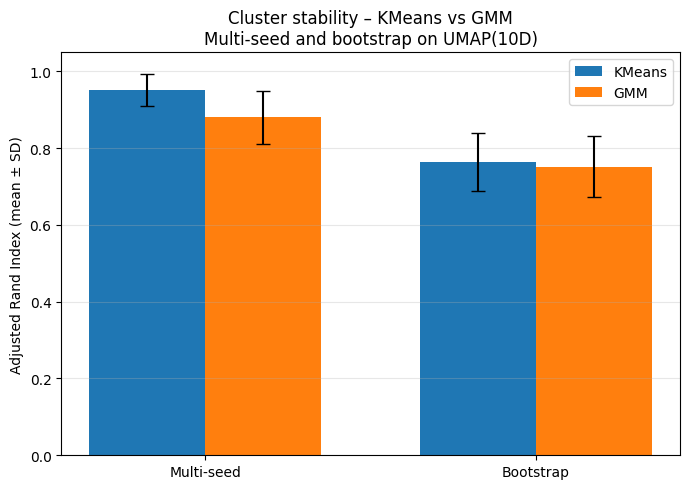

MEANING: nothing random about the way things were extracted, changing the seed comes to similar results. so what about the null hypothesis, that says that the blobs dont do anything by shuffling the maps randomly and seeing how the result are


In [108]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute means and stds ---
mean_km_seed  = kmeans_ari_vals.mean()
std_km_seed   = kmeans_ari_vals.std()
mean_gmm_seed = gmm_ari_vals.mean()
std_gmm_seed  = gmm_ari_vals.std()

mean_km_boot  = kmeans_boot_vals.mean()
std_km_boot   = kmeans_boot_vals.std()
mean_gmm_boot = gmm_boot_vals.mean()
std_gmm_boot  = gmm_boot_vals.std()

print("KMeans  multi-seed  ARI: mean =", mean_km_seed,  "std =", std_km_seed)
print("GMM     multi-seed  ARI: mean =", mean_gmm_seed, "std =", std_gmm_seed)
print("KMeans  bootstrap   ARI: mean =", mean_km_boot,  "std =", std_km_boot)
print("GMM     bootstrap   ARI: mean =", mean_gmm_boot, "std =", std_gmm_boot)

# --- One summary plot: mean ± SD ARI ---
labels = ["Multi-seed", "Bootstrap"]
x = np.arange(len(labels))  # [0, 1]
width = 0.35                # bar width

kmeans_means = [mean_km_seed,  mean_km_boot]
kmeans_stds  = [std_km_seed,   std_km_boot]

gmm_means    = [mean_gmm_seed, mean_gmm_boot]
gmm_stds     = [std_gmm_seed,  std_gmm_boot]

fig, ax = plt.subplots(figsize=(7, 5))

# KMeans bars (left in each group)
ax.bar(
    x - width/2,
    kmeans_means,
    width,
    yerr=kmeans_stds,
    capsize=5,
    label="KMeans",
)

# GMM bars (right in each group)
ax.bar(
    x + width/2,
    gmm_means,
    width,
    yerr=gmm_stds,
    capsize=5,
    label="GMM",
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Adjusted Rand Index (mean ± SD)")
ax.set_title("Cluster stability – KMeans vs GMM\nMulti-seed and bootstrap on UMAP(10D)")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
print("MEANING: nothing random about the way things were extracted, changing the seed comes to similar results. so what about the null hypothesis, that says that the blobs dont do anything by shuffling the maps randomly and seeing how the result are")

Idea (tiny explanation)

Goal:
Test whether the structure in your 10D UMAP + KMeans/GMM is more than you’d expect from “ERSP noise with the same marginal distribution”.

What we do:

Destroy the blob geometry in each ERSP by randomly shuffling its pixels:

Keeps the same global value distribution (same histogram of dB values),

But kills spatial contiguity / blob shapes in time–frequency.

Recompute UMAP(10D) on these shuffled maps.

Re-run KMeans & GMM (K=9) on the null embedding.

Collect:

Silhouette scores for KMeans and GMM on the null data.

ARI between real vs null clusters (for each null run).

Compare:

Real silhouettes vs null silhouette distribution.

ARI(real, null) distribution (should be near 0 if real solution is not what random ERSPs would produce).

If real data gives silhouette >> null and ARI(real, null) ~ 0, you can say your clusters reflect real spatiotemporal structure, not just the value distribution.

Null model: 20 runs, ERSP shape = (129, 300), n_samples = 399
Real KMeans silhouette (K=10): 0.5213
Real GMM    silhouette (K=9): 0.5178

--- Null run 1/20 ---


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  X_null_10d shape: (399, 10)
  KMeans null silhouette: 0.2589, ARI vs real KMeans: 0.0460
  GMM    null silhouette: 0.2217, ARI vs real GMM: 0.0367

--- Null run 2/20 ---


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  X_null_10d shape: (399, 10)
  KMeans null silhouette: 0.2447, ARI vs real KMeans: 0.0485
  GMM    null silhouette: 0.2120, ARI vs real GMM: 0.0446

--- Null run 3/20 ---


...

  X_null_10d shape: (399, 10)
  KMeans null silhouette: 0.2377, ARI vs real KMeans: 0.0430
  GMM    null silhouette: 0.2117, ARI vs real GMM: 0.0410

--- Null run 19/20 ---


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  X_null_10d shape: (399, 10)
  KMeans null silhouette: 0.2281, ARI vs real KMeans: 0.0466
  GMM    null silhouette: 0.2083, ARI vs real GMM: 0.0426

--- Null run 20/20 ---


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  X_null_10d shape: (399, 10)
  KMeans null silhouette: 0.2239, ARI vs real KMeans: 0.0407
  GMM    null silhouette: 0.1863, ARI vs real GMM: 0.0374

=== Null model summary ===
KMeans real silhouette: 0.5213
KMeans null silhouettes: mean=0.2372, std=0.0099, min=0.2190, max=0.2589
GMM real silhouette: 0.5178
GMM null silhouettes: mean=0.2125, std=0.0142, min=0.1750, max=0.2423
KMeans ARI(real vs null): mean=0.0429, std=0.0029, min=0.0369, max=0.0485
GMM ARI(real vs null): mean=0.0397, std=0.0052, min=0.0351, max=0.0544


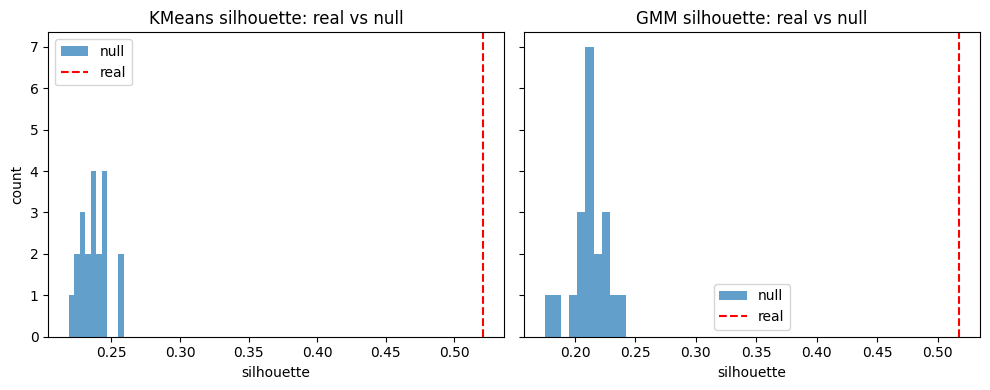

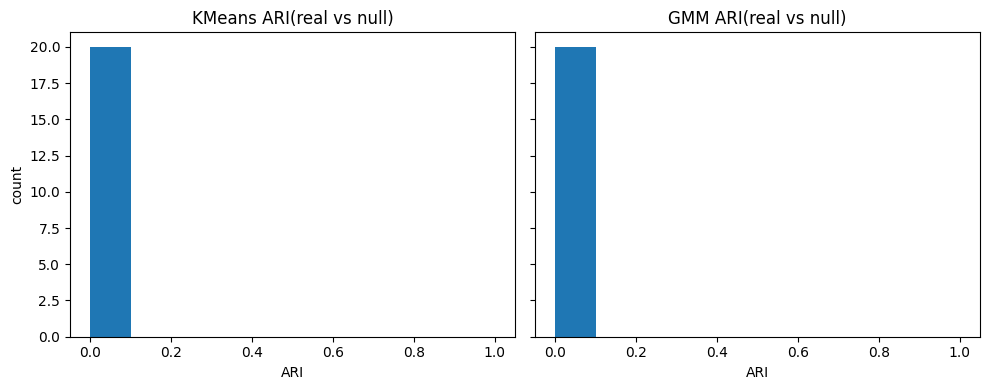

In [109]:
import numpy as np
import umap
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

N_NULL_RUNS = 20  # number of null datasets (increase later if needed)
N_FREQ, N_TIME = ersp_list[0].shape

print(f"Null model: {N_NULL_RUNS} runs, ERSP shape = ({N_FREQ}, {N_TIME}), "
      f"n_samples = {len(ersp_list)}")

# Sanity: real silhouette for reference (in 10D space you already have)
real_kmeans_sil = silhouette_score(X_for_clustering, best_kmeans_labels)
real_gmm_sil    = silhouette_score(X_for_clustering, best_gmm_labels)
print(f"Real KMeans silhouette (K={best_K_kmeans}): {real_kmeans_sil:.4f}")
print(f"Real GMM    silhouette (K={best_K_gmm}): {real_gmm_sil:.4f}")

# ============================================================
# Helper: shuffle a single ERSP array
# ============================================================

def shuffle_ersp_array(arr, rng):
    """
    arr: 2D array (N_FREQ, N_TIME)
    rng: np.random.Generator
    Returns a new array with the same values but randomly permuted positions.
    This destroys blob geometry but preserves the marginal distribution.
    """
    flat = arr.reshape(-1).copy()
    rng.shuffle(flat)
    return flat.reshape(arr.shape)


# ============================================================
# Main null loop
# ============================================================

kmeans_sil_null = []
gmm_sil_null = []
kmeans_ari_null_vs_real = []
gmm_ari_null_vs_real = []

for run in range(N_NULL_RUNS):
    print(f"\n--- Null run {run+1}/{N_NULL_RUNS} ---")
    rng = np.random.default_rng(RANDOM_STATE + 5000 + run)

    # 1) Build shuffled ERSP list
    ersp_list_null = [shuffle_ersp_array(arr, rng) for arr in ersp_list]

    # 2) Flatten null ERSPs -> big feature matrix (F*T)
    X_null_flat = np.empty((len(ersp_list_null), N_FREQ * N_TIME), dtype=np.float32)
    for i, arr in enumerate(ersp_list_null):
        X_null_flat[i, :] = arr.reshape(-1)

    # 3) UMAP(10D) on null maps, same params as real
    reducer_null = umap.UMAP(
        n_neighbors=30,
        min_dist=0.05,
        n_components=10,
        metric="euclidean",
        random_state=RANDOM_STATE + 6000 + run,
    )
    X_null_10d = reducer_null.fit_transform(X_null_flat)
    print("  X_null_10d shape:", X_null_10d.shape)

    # 4) KMeans on null
    km_null = KMeans(
        n_clusters=best_K_kmeans,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE + 7000 + run,
        verbose=0,
    )
    km_null.fit(X_null_10d)
    labels_null_km = km_null.labels_

    sil_km = silhouette_score(X_null_10d, labels_null_km)
    kmeans_sil_null.append(sil_km)

    # compare to REAL KMeans clustering on REAL data (same sample indices)
    ari_km = adjusted_rand_score(best_kmeans_labels, labels_null_km)
    kmeans_ari_null_vs_real.append(ari_km)

    print(f"  KMeans null silhouette: {sil_km:.4f}, ARI vs real KMeans: {ari_km:.4f}")

    # 5) GMM on null
    gmm_null = GaussianMixture(
        n_components=best_K_gmm,
        covariance_type="diag",
        random_state=RANDOM_STATE + 8000 + run,
        n_init=5,
        max_iter=300,
    )
    gmm_null.fit(X_null_10d)
    labels_null_gmm = gmm_null.predict(X_null_10d)

    sil_gmm = silhouette_score(X_null_10d, labels_null_gmm)
    gmm_sil_null.append(sil_gmm)

    ari_gmm = adjusted_rand_score(best_gmm_labels, labels_null_gmm)
    gmm_ari_null_vs_real.append(ari_gmm)

    print(f"  GMM    null silhouette: {sil_gmm:.4f}, ARI vs real GMM: {ari_gmm:.4f}")

kmeans_sil_null = np.array(kmeans_sil_null)
gmm_sil_null    = np.array(gmm_sil_null)
kmeans_ari_null_vs_real = np.array(kmeans_ari_null_vs_real)
gmm_ari_null_vs_real    = np.array(gmm_ari_null_vs_real)

# ============================================================
# Summary + quick plots
# ============================================================

print("\n=== Null model summary ===")

print(f"KMeans real silhouette: {real_kmeans_sil:.4f}")
print(f"KMeans null silhouettes: mean={kmeans_sil_null.mean():.4f}, "
      f"std={kmeans_sil_null.std():.4f}, "
      f"min={kmeans_sil_null.min():.4f}, max={kmeans_sil_null.max():.4f}")

print(f"GMM real silhouette: {real_gmm_sil:.4f}")
print(f"GMM null silhouettes: mean={gmm_sil_null.mean():.4f}, "
      f"std={gmm_sil_null.std():.4f}, "
      f"min={gmm_sil_null.min():.4f}, max={gmm_sil_null.max():.4f}")

print(f"KMeans ARI(real vs null): mean={kmeans_ari_null_vs_real.mean():.4f}, "
      f"std={kmeans_ari_null_vs_real.std():.4f}, "
      f"min={kmeans_ari_null_vs_real.min():.4f}, max={kmeans_ari_null_vs_real.max():.4f}")

print(f"GMM ARI(real vs null): mean={gmm_ari_null_vs_real.mean():.4f}, "
      f"std={gmm_ari_null_vs_real.std():.4f}, "
      f"min={gmm_ari_null_vs_real.min():.4f}, max={gmm_ari_null_vs_real.max():.4f}")

# --- Silhouette comparison plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# KMeans
axes[0].hist(kmeans_sil_null, bins=10, alpha=0.7, label="null")
axes[0].axvline(real_kmeans_sil, color="red", linestyle="--", label="real")
axes[0].set_title("KMeans silhouette: real vs null")
axes[0].set_xlabel("silhouette")
axes[0].set_ylabel("count")
axes[0].legend()

# GMM
axes[1].hist(gmm_sil_null, bins=10, alpha=0.7, label="null")
axes[1].axvline(real_gmm_sil, color="red", linestyle="--", label="real")
axes[1].set_title("GMM silhouette: real vs null")
axes[1].set_xlabel("silhouette")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- ARI(real vs null) plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(kmeans_ari_null_vs_real, bins=10, range=(0, 1))
axes[0].set_title("KMeans ARI(real vs null)")
axes[0].set_xlabel("ARI")
axes[0].set_ylabel("count")

axes[1].hist(gmm_ari_null_vs_real, bins=10, range=(0, 1))
axes[1].set_title("GMM ARI(real vs null)")
axes[1].set_xlabel("ARI")

plt.tight_layout()
plt.show()


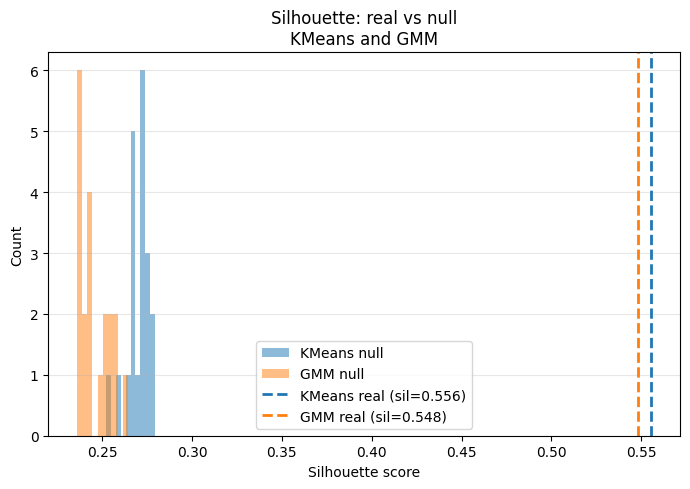

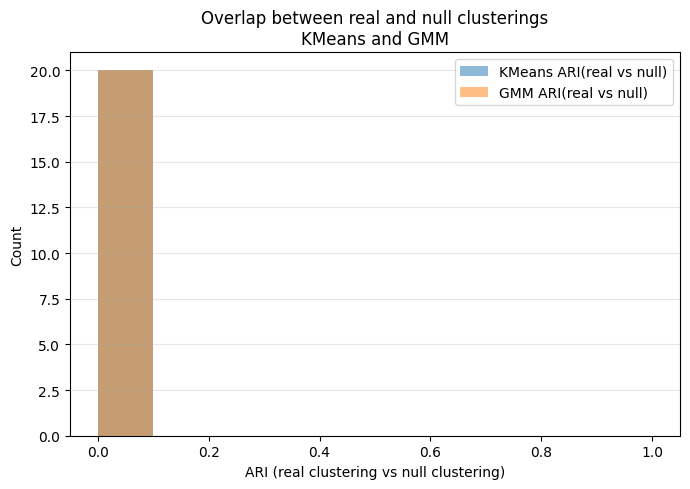

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1) Silhouette: real vs null in the SAME plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

bins = 10

# Null histograms (slightly transparent)
ax.hist(
    kmeans_sil_null,
    bins=bins,
    alpha=0.5,
    label="KMeans null",
)
ax.hist(
    gmm_sil_null,
    bins=bins,
    alpha=0.5,
    label="GMM null",
)

# Real silhouettes as vertical lines
ax.axvline(real_kmeans_sil, color="C0", linestyle="--", linewidth=2,
           label=f"KMeans real (sil={real_kmeans_sil:.3f})")
ax.axvline(real_gmm_sil,    color="C1", linestyle="--", linewidth=2,
           label=f"GMM real (sil={real_gmm_sil:.3f})")

ax.set_xlabel("Silhouette score")
ax.set_ylabel("Count")
ax.set_title("Silhouette: real vs null\nKMeans and GMM")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2) ARI(real vs null): both algos on one plot
#     (how similar are null clusterings to the real ones)
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

bins = np.linspace(0, 1, 11)

ax.hist(
    kmeans_ari_null_vs_real,
    bins=bins,
    alpha=0.5,
    label="KMeans ARI(real vs null)",
)
ax.hist(
    gmm_ari_null_vs_real,
    bins=bins,
    alpha=0.5,
    label="GMM ARI(real vs null)",
)

ax.set_xlabel("ARI (real clustering vs null clustering)")
ax.set_ylabel("Count")
ax.set_title("Overlap between real and null clusterings\nKMeans and GMM")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [78]:
import numpy as np

def summarize_real_vs_null(real_value, null_values, label):
    null_values = np.asarray(null_values)
    mean_null = np.nanmean(null_values)
    std_null  = np.nanstd(null_values)

    # z-score (how many stds above/below null mean)
    if std_null > 0:
        z = (real_value - mean_null) / std_null
    else:
        z = np.nan

    # empirical p-value: how often does null >= real?
    # (for silhouette & ARI where larger = better)
    p_emp = np.mean(null_values >= real_value)

    print(f"\n=== {label} ===")
    print(f"Real value          : {real_value:.4f}")
    print(f"Null mean ± SD      : {mean_null:.4f} ± {std_null:.4f}")
    print(f"Z-score (real vs null mean): {z:.2f}")
    print(f"Empirical p (null ≥ real)  : {p_emp:.4f}")

# --- silhouettes ---
summarize_real_vs_null(real_kmeans_sil, kmeans_sil_null, "KMeans silhouette")
summarize_real_vs_null(real_gmm_sil,    gmm_sil_null,    "GMM silhouette")

# --- ARI (real vs null) ---
# here, "real" reference is 0 (if clusters were unrelated, ARI≈0),
# and the null distribution is ARI(real vs null) you already computed.
# We actually want to see if ARI is *close to 0*, so we can also
# look at |ARI| compared to distribution.
summarize_real_vs_null(
    0.0, np.abs(kmeans_ari_null_vs_real), "KMeans |ARI(real vs null)| (expect small)"
)
summarize_real_vs_null(
    0.0, np.abs(gmm_ari_null_vs_real), "GMM |ARI(real vs null)| (expect small)"
)



=== KMeans silhouette ===
Real value          : 0.5555
Null mean ± SD      : 0.2698 ± 0.0063
Z-score (real vs null mean): 45.69
Empirical p (null ≥ real)  : 0.0000

=== GMM silhouette ===
Real value          : 0.5483
Null mean ± SD      : 0.2457 ± 0.0085
Z-score (real vs null mean): 35.67
Empirical p (null ≥ real)  : 0.0000

=== KMeans |ARI(real vs null)| (expect small) ===
Real value          : 0.0000
Null mean ± SD      : 0.0617 ± 0.0035
Z-score (real vs null mean): -17.61
Empirical p (null ≥ real)  : 1.0000

=== GMM |ARI(real vs null)| (expect small) ===
Real value          : 0.0000
Null mean ± SD      : 0.0529 ± 0.0030
Z-score (real vs null mean): -17.61
Empirical p (null ≥ real)  : 1.0000


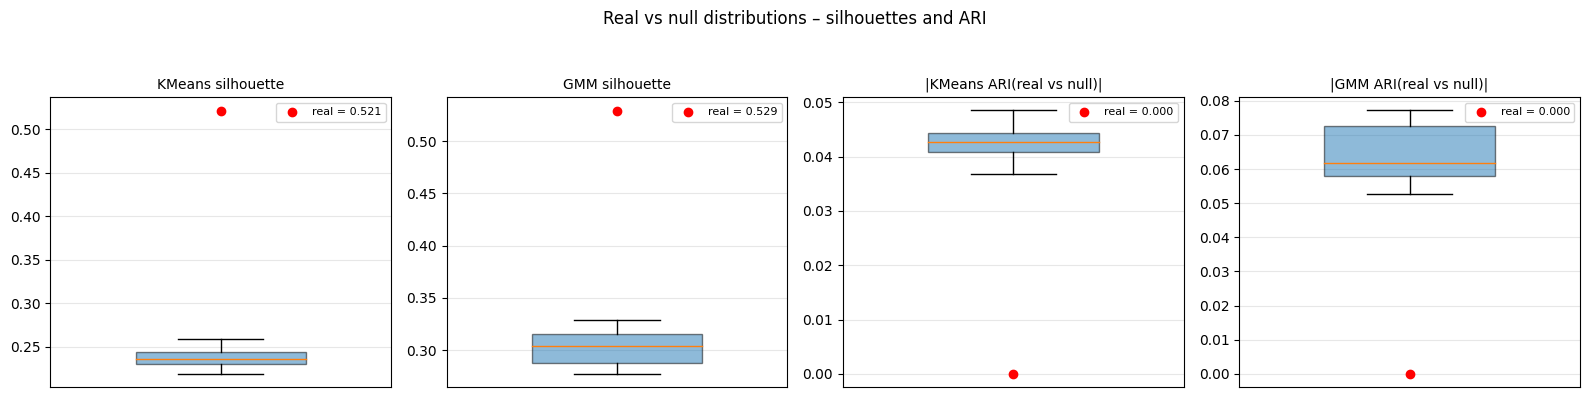

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# Collect metrics in a compact structure
metrics = [
    ("KMeans silhouette", real_kmeans_sil, kmeans_sil_null),
    ("GMM silhouette",    real_gmm_sil,    gmm_sil_null),
    ("|KMeans ARI(real vs null)|", 0.0, np.abs(kmeans_ari_null_vs_real)),
    ("|GMM ARI(real vs null)|",    0.0, np.abs(gmm_ari_null_vs_real)),
]

n_metrics = len(metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), sharey=False)

if n_metrics == 1:
    axes = [axes]

for ax, (title, real_val, null_vals) in zip(axes, metrics):
    null_vals = np.asarray(null_vals)

    # Boxplot for null
    bp = ax.boxplot(
        null_vals,
        positions=[0],
        widths=0.5,
        showfliers=True,
        patch_artist=True,
    )
    for patch in bp['boxes']:
        patch.set_alpha(0.5)

    # Real value as a dot
    ax.scatter(
        [0],
        [real_val],
        color="red",
        zorder=3,
        label=f"real = {real_val:.3f}",
    )

    ax.set_xticks([])
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, loc="best")

plt.suptitle("Real vs null distributions – silhouettes and ARI", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


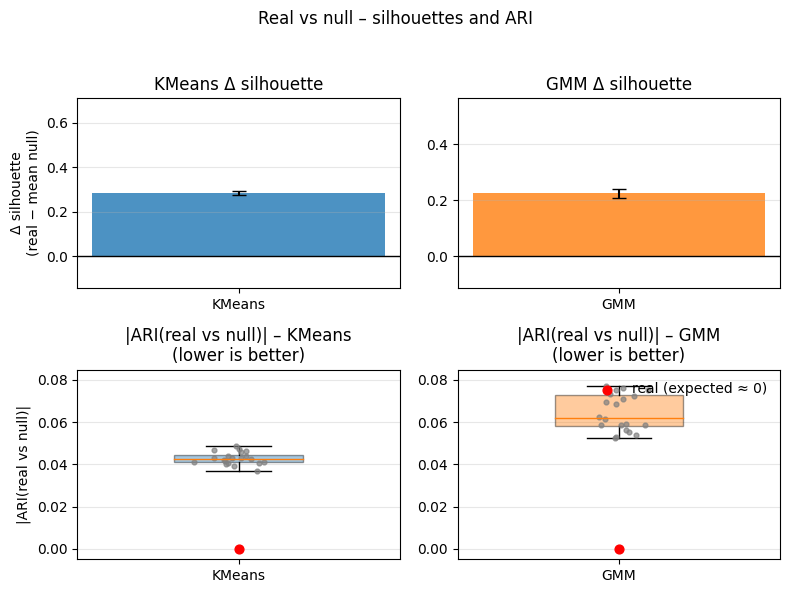

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# --- Make sure these exist from previous steps ---
# real_kmeans_sil, real_gmm_sil
# kmeans_sil_null, gmm_sil_null
# kmeans_ari_null_vs_real, gmm_ari_null_vs_real

km_null_sil = np.asarray(kmeans_sil_null)
gm_null_sil = np.asarray(gmm_sil_null)

km_null_ari = np.abs(np.asarray(kmeans_ari_null_vs_real))
gm_null_ari = np.abs(np.asarray(gmm_ari_null_vs_real))

# --- Δ silhouette stats ---
km_sil_mean = km_null_sil.mean()
km_sil_std  = km_null_sil.std(ddof=1)
gm_sil_mean = gm_null_sil.mean()
gm_sil_std  = gm_null_sil.std(ddof=1)

km_delta = real_kmeans_sil - km_sil_mean
gm_delta = real_gmm_sil    - gm_sil_mean

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
(ax11, ax12), (ax21, ax22) = axes

# ======================================================
# Top row: Δ silhouette (real - mean(null))
# ======================================================

# KMeans
ax11.bar(
    [0],
    [km_delta],
    yerr=[km_sil_std],
    capsize=5,
    color="C0",
    alpha=0.8,
)
ax11.axhline(0, color="k", linewidth=1)
ax11.set_xticks([0])
ax11.set_xticklabels(["KMeans"])
ax11.set_ylabel("Δ silhouette\n(real − mean null)")
ax11.set_title("KMeans Δ silhouette")
ax11.grid(axis="y", alpha=0.3)

# GMM
ax12.bar(
    [0],
    [gm_delta],
    yerr=[gm_sil_std],
    capsize=5,
    color="C1",
    alpha=0.8,
)
ax12.axhline(0, color="k", linewidth=1)
ax12.set_xticks([0])
ax12.set_xticklabels(["GMM"])
ax12.set_title("GMM Δ silhouette")
ax12.grid(axis="y", alpha=0.3)

# Tight y-lims around bars
for ax, delta in zip([ax11, ax12], [km_delta, gm_delta]):
    span = max(abs(delta) * 1.5, 0.05)
    ax.set_ylim(delta - span, delta + span)

# ======================================================
# Bottom row: |ARI(real vs null)| (lower is better)
# ======================================================

# KMeans ARI
bp_km = ax21.boxplot(
    km_null_ari,
    positions=[0],
    widths=0.4,
    showfliers=True,
    patch_artist=True,
)
for box in bp_km["boxes"]:
    box.set_facecolor("C0")
    box.set_alpha(0.4)

# jittered null points
rng = np.random.default_rng(0)
x_jitter = 0 + 0.06 * rng.normal(size=km_null_ari.shape[0])
ax21.scatter(
    x_jitter,
    km_null_ari,
    color="gray",
    s=12,
    alpha=0.7,
    zorder=2,
)

# real ARI (0) as red dot
ax21.scatter(
    0,
    0.0,
    color="red",
    s=40,
    zorder=3,
    label="real (expected ≈ 0)",
)
ax21.set_xticks([0])
ax21.set_xticklabels(["KMeans"])
ax21.set_ylabel(r"|ARI(real vs null)|")
ax21.set_title("|ARI(real vs null)| – KMeans\n(lower is better)")
ax21.grid(axis="y", alpha=0.3)

# GMM ARI
bp_gm = ax22.boxplot(
    gm_null_ari,
    positions=[0],
    widths=0.4,
    showfliers=True,
    patch_artist=True,
)
for box in bp_gm["boxes"]:
    box.set_facecolor("C1")
    box.set_alpha(0.4)

x_jitter = 0 + 0.06 * rng.normal(size=gm_null_ari.shape[0])
ax22.scatter(
    x_jitter,
    gm_null_ari,
    color="gray",
    s=12,
    alpha=0.7,
    zorder=2,
)

ax22.scatter(
    0,
    0.0,
    color="red",
    s=40,
    zorder=3,
    label="real (expected ≈ 0)",
)
ax22.set_xticks([0])
ax22.set_xticklabels(["GMM"])
ax22.set_title("|ARI(real vs null)| – GMM\n(lower is better)")
ax22.grid(axis="y", alpha=0.3)

# Match y-lims for ARI panels
ari_max = max(km_null_ari.max(), gm_null_ari.max()) * 1.1
ax21.set_ylim(-0.005, ari_max)
ax22.set_ylim(-0.005, ari_max)

# Shared legend for ARI panels
handles, labels_ = ax21.get_legend_handles_labels()
ax22.legend(handles, labels_, frameon=False, loc="upper right")

fig.suptitle("Real vs null – silhouettes and ARI", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


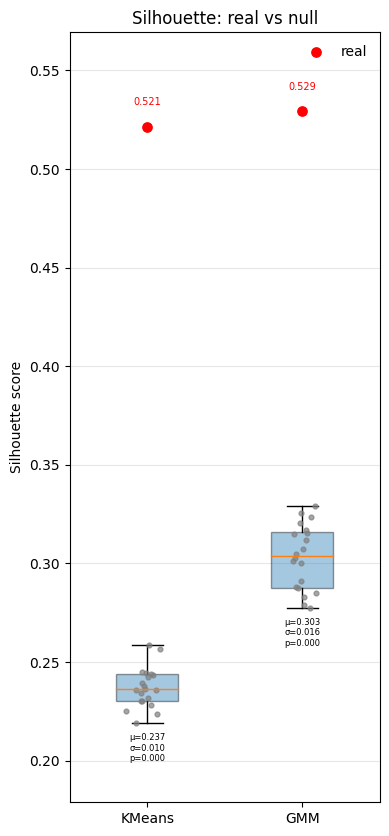

In [102]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure these are numpy arrays
km_null = np.asarray(kmeans_sil_null)
gm_null = np.asarray(gmm_sil_null)

labels     = ["KMeans", "GMM"]
null_sets  = [km_null, gm_null]
real_vals  = [real_kmeans_sil, real_gmm_sil]

fig, ax = plt.subplots(figsize=(4, 10))

# -------------------------
# Boxplots for null values
# -------------------------
bp = ax.boxplot(
    null_sets,
    positions=np.arange(len(labels)),
    widths=0.4,
    showmeans=False,
    showfliers=False,
    patch_artist=True,
)

for box in bp["boxes"]:
    box.set_alpha(0.4)

# -------------------------
# Jittered null points
# -------------------------
rng = np.random.default_rng(0)
for i, null_vals in enumerate(null_sets):
    x_jitter = i + 0.06 * rng.normal(size=null_vals.shape[0])
    ax.scatter(
        x_jitter,
        null_vals,
        color="gray",
        s=12,
        alpha=0.7,
        zorder=2,
    )

# -------------------------
# Real values as red dots
# + small text label
# -------------------------
for i, rv in enumerate(real_vals):
    ax.scatter(
        i,
        rv,
        color="red",
        s=45,
        zorder=3,
        label="real" if i == 0 else None,
    )
    ax.text(
        i,
        rv + 0.01,
        f"{rv:.3f}",
        ha="center",
        va="bottom",
        fontsize=7,
        color="red",
    )

# -------------------------
# Optional: annotate null mean/std and empirical p
# p = fraction of null >= real (one-sided, “is real better?”)
# -------------------------
for i, (label, null_vals, rv) in enumerate(zip(labels, null_sets, real_vals)):
    mean_null = null_vals.mean()
    std_null  = null_vals.std(ddof=1)
    p_emp     = (null_vals >= rv).mean()

    ax.text(
        i,
        null_vals.min() - 0.005,
        f"μ={mean_null:.3f}\nσ={std_null:.3f}\np={p_emp:.3f}",
        ha="center",
        va="top",
        fontsize=6,
    )

# Axes formatting
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette: real vs null")

# Keep y-range tight but not crazy
y_min = min(km_null.min(), gm_null.min()) - 0.04
y_max = max(real_vals) + 0.04
ax.set_ylim(y_min, y_max)

ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)


C:\Users\artoni\AppData\Local\Temp\ipykernel_6784\1300978290.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


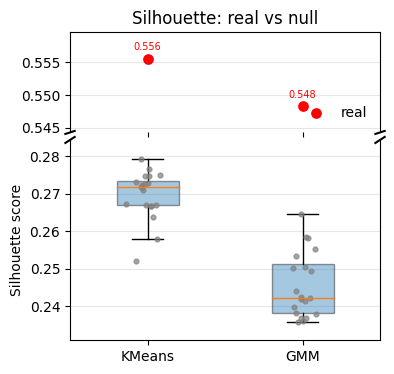

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Data
km_null = np.asarray(kmeans_sil_null)
gm_null = np.asarray(gmm_sil_null)

labels    = ["KMeans", "GMM"]
null_sets = [km_null, gm_null]
real_vals = [real_kmeans_sil, real_gmm_sil]

positions = np.arange(len(labels))

# -------------------------------------------------
# Two stacked axes sharing x: TOP = real, BOTTOM = null
# -------------------------------------------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(4, 4),
    gridspec_kw={"height_ratios": [1, 2], "hspace": 0.05},
)

# -----------------------------
# Bottom axis: null (box + jitter)
# -----------------------------
bp = ax_bottom.boxplot(
    null_sets,
    positions=positions,
    widths=0.4,
    showmeans=False,
    showfliers=False,
    patch_artist=True,
)

for box in bp["boxes"]:
    box.set_alpha(0.4)

rng = np.random.default_rng(0)
for i, null_vals in enumerate(null_sets):
    x_jitter = i + 0.06 * rng.normal(size=null_vals.shape[0])
    ax_bottom.scatter(
        x_jitter,
        null_vals,
        color="gray",
        s=12,
        alpha=0.7,
        zorder=2,
    )

# Y-limits for null region
null_min = min(km_null.min(), gm_null.min()) - 0.005
null_max = max(km_null.max(), gm_null.max()) + 0.005
ax_bottom.set_ylim(null_min, null_max)

# -----------------------------
# Top axis: real silhouettes only
# -----------------------------
for i, rv in enumerate(real_vals):
    ax_top.scatter(
        positions[i],
        rv,
        color="red",
        s=45,
        zorder=3,
        label="real" if i == 0 else None,
    )
    ax_top.text(
        positions[i],
        rv + 0.001,
        f"{rv:.3f}",
        ha="center",
        va="bottom",
        fontsize=7,
        color="red",
    )

real_min = min(real_vals) - 0.004
real_max = max(real_vals) + 0.007
ax_top.set_ylim(real_min, real_max)

# -----------------------------
# Broken-axis cosmetics
# -----------------------------
# Hide touching spines
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)

ax_top.tick_params(labelbottom=False)  # no x labels on top
ax_bottom.xaxis.tick_bottom()

# Diagonal break marks
d = 0.015
kwargs_top = dict(transform=ax_top.transAxes, color="k", clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs_top)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs_top)

kwargs_bot = dict(transform=ax_bottom.transAxes, color="k", clip_on=False)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs_bot)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_bot)

# Labels / title
ax_bottom.set_xticks(positions)
ax_bottom.set_xticklabels(labels)
ax_bottom.set_ylabel("Silhouette score")
ax_top.set_title("Silhouette: real vs null")

ax_bottom.grid(axis="y", alpha=0.3)
ax_top.grid(axis="y",   alpha=0.3)
ax_top.legend(frameon=True, loc="lower right")

plt.tight_layout()
plt.show()


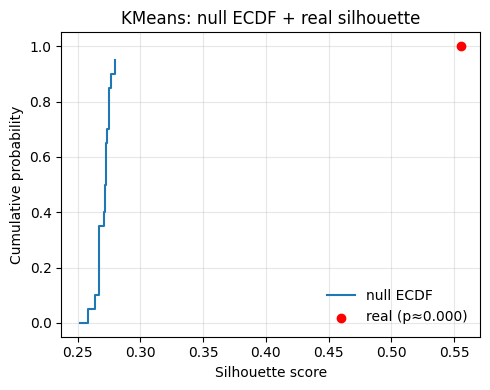

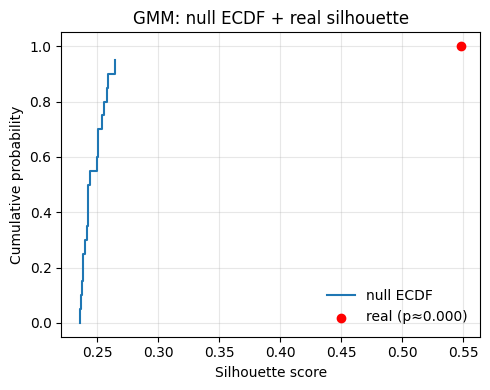

In [80]:
def plot_ecdf_with_real(null_vals, real_val, title):
    null_vals = np.sort(np.asarray(null_vals))
    n = len(null_vals)
    y = np.linspace(0, 1, n, endpoint=False)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.step(null_vals, y, where="post", label="null ECDF")

    # Real value
    # empirical percentile = fraction of null <= real
    perc = (null_vals <= real_val).mean()

    ax.scatter(
        [real_val], [perc],
        color="red",
        zorder=3,
        label=f"real (p≈{1-perc:.3f})",
    )

    ax.set_xlabel("Silhouette score")
    ax.set_ylabel("Cumulative probability")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

# KMeans
plot_ecdf_with_real(
    kmeans_sil_null,
    real_kmeans_sil,
    "KMeans: null ECDF + real silhouette"
)

# GMM
plot_ecdf_with_real(
    gmm_sil_null,
    real_gmm_sil,
    "GMM: null ECDF + real silhouette"
)


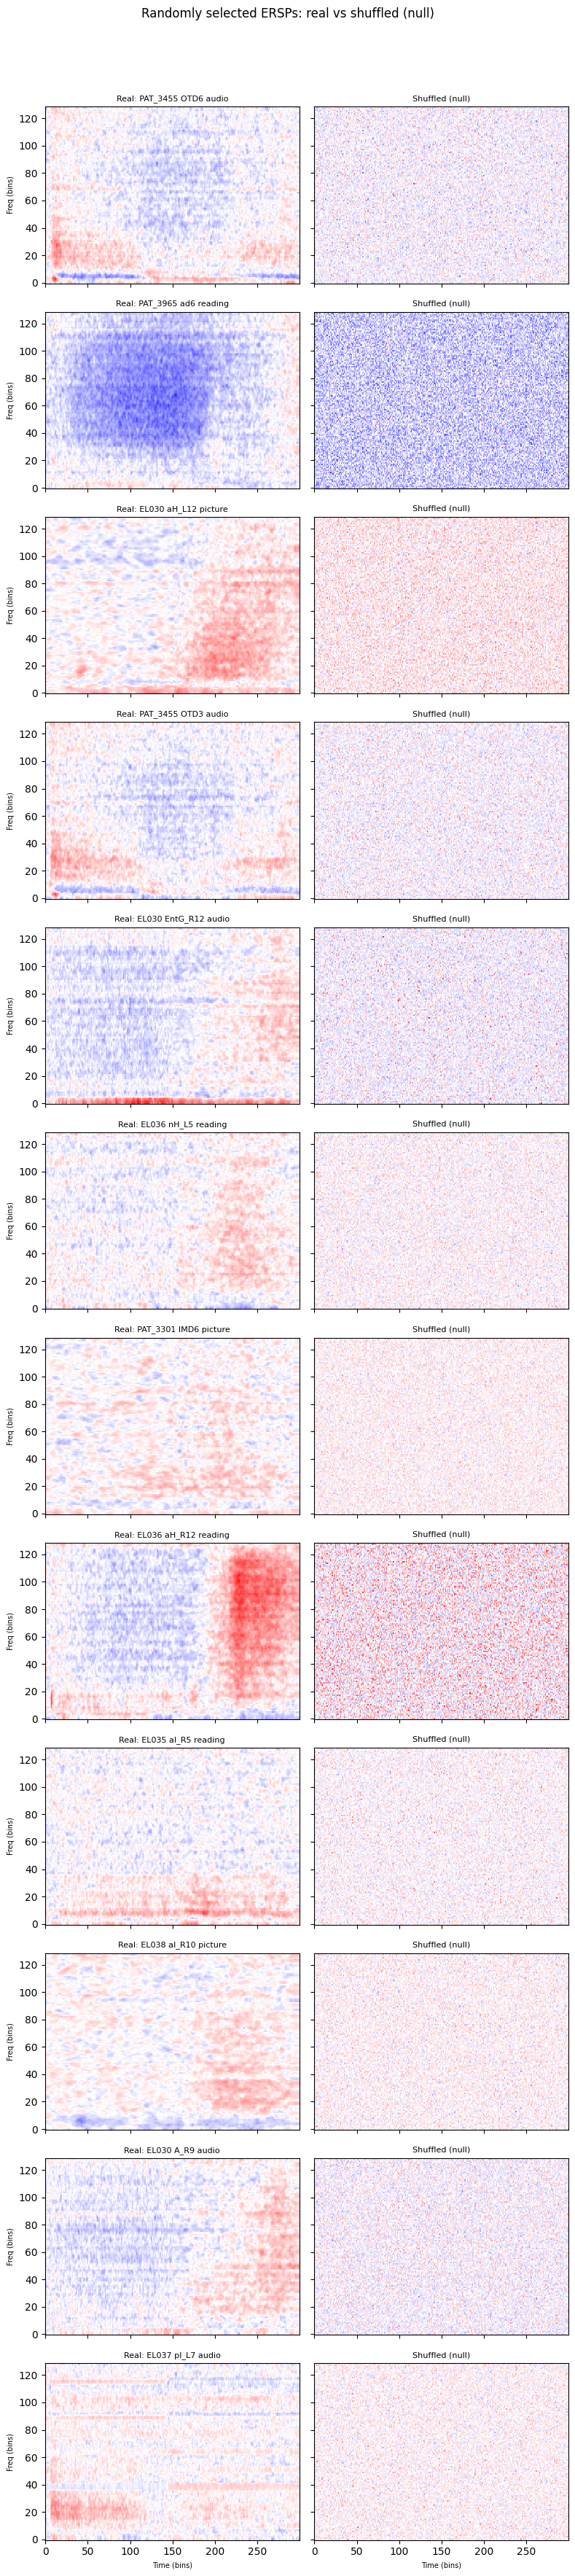

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# How many electrodes to show
N_EXAMPLES = 12   # adjust if you want more/less

rng = np.random.default_rng(RANDOM_STATE + 9000)

# Random unique electrode indices
indices = rng.choice(len(ersp_list), size=min(N_EXAMPLES, len(ersp_list)), replace=False)

# Compute a symmetric color scale from the selected REAL ERSPs
vals = []
for idx in indices:
    arr = ersp_list[idx]
    vals.append(arr.ravel())
vals = np.concatenate(vals)
v = np.nanmax(np.abs(vals))
vmin, vmax = -v, v  # or fix to -5, 5 if you prefer

n_rows = len(indices)
fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(8, 3 * n_rows),
    sharex=True,
    sharey=True
)

# Ensure axes is 2D array even if n_rows == 1
if n_rows == 1:
    axes = np.array([axes])

for row, idx in enumerate(indices):
    real = ersp_list[idx]
    shuffled = shuffle_ersp_array(real, rng)

    ax_real = axes[row, 0]
    ax_null = axes[row, 1]

    im0 = ax_real.imshow(
        real,
        origin="lower",
        aspect="auto",
        cmap="bwr",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    ax_real.set_ylabel("Freq (bins)", fontsize=7)

    im1 = ax_null.imshow(
        shuffled,
        origin="lower",
        aspect="auto",
        cmap="bwr",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    meta = df_meta.iloc[idx]
    ax_real.set_title(
        f"Real: {meta['patient_id']} {meta['electrode']} {meta['condition']}",
        fontsize=8
    )
    ax_null.set_title("Shuffled (null)", fontsize=8)

# X labels only on bottom row
for ax in axes[-1, :]:
    ax.set_xlabel("Time (bins)", fontsize=7)

fig.suptitle(
    "Randomly selected ERSPs: real vs shuffled (null)",
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
